<a href="https://colab.research.google.com/github/xiyuan1avery/ma2288/blob/research-v3/notebooks/22_train_multihorizon_nextlat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 22 — Multi-Horizon NextLat Training

## Objective

This notebook tests whether explicit multi-step joint training improves
long-horizon latent prediction compared with the matched horizon-1 NextLat
model trained in Notebook 21.

Primary comparison:

- NextLat with `mtp_horizon = 1`
- NextLat with `mtp_horizon = 8`

All shared settings are matched:

- Official NextLat commit
- TinyStories dataset
- Model architecture
- Training steps and tokens
- Batch size
- Optimizer
- Random seed
- Precision
- GPU class

## Primary hypothesis

Explicit horizon-8 training will reduce long-horizon latent error and
decoder output KL without causing an unacceptable degradation in
next-token perplexity or training cost.

## Stop/go criterion

Continue to cross-seed and out-of-distribution evaluation only if the
horizon-8 model produces a meaningful improvement at rollout horizons
4 and 8 while retaining reasonable language-modeling quality.

In [1]:
# Cell 2 — Mount Drive and define project paths

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/ma2288_nextlat"
)

V3_ROOT = PROJECT_ROOT / "research_v3"

V3_CONFIG_DIR = (
    V3_ROOT
    / "configs"
    / "multihorizon"
)

V3_CHECKPOINT_DIR = (
    V3_ROOT
    / "checkpoints"
)

V3_TABLES_DIR = (
    V3_ROOT
    / "results"
    / "tables"
)

V3_METADATA_DIR = (
    V3_ROOT
    / "results"
    / "metadata"
)

V3_FIGURES_DIR = (
    V3_ROOT
    / "results"
    / "figures"
)

for directory in [
    V3_CONFIG_DIR,
    V3_CHECKPOINT_DIR,
    V3_TABLES_DIR,
    V3_METADATA_DIR,
    V3_FIGURES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print("Project root:", PROJECT_ROOT)
print("V3 root:", V3_ROOT)
print("Config directory:", V3_CONFIG_DIR)
print("Checkpoint directory:", V3_CHECKPOINT_DIR)

Mounted at /content/drive
Project root: /content/drive/MyDrive/ma2288_nextlat
V3 root: /content/drive/MyDrive/ma2288_nextlat/research_v3
Config directory: /content/drive/MyDrive/ma2288_nextlat/research_v3/configs/multihorizon
Checkpoint directory: /content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints


In [2]:
# Cell 3 — Environment check

import platform
import subprocess
import sys
import torch

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

assert torch.cuda.is_available()

print("GPU:", torch.cuda.get_device_name(0))
print(
    "GPU memory GB:",
    round(
        torch.cuda.get_device_properties(0).total_memory
        / 1024**3,
        2,
    ),
)
print(
    "BF16 supported:",
    torch.cuda.is_bf16_supported(),
)

print("\nnvidia-smi:")
result = subprocess.run(
    [
        "nvidia-smi",
        "--query-gpu=name,memory.total,memory.free",
        "--format=csv,noheader",
    ],
    capture_output=True,
    text=True,
)

print(result.stdout)

assert "L4" in torch.cuda.get_device_name(0)
assert torch.cuda.is_bf16_supported()

print("Notebook 22 environment check passed.")

Python: 3.12.13
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA L4
GPU memory GB: 22.03
BF16 supported: True

nvidia-smi:
NVIDIA L4, 23034 MiB, 22561 MiB

Notebook 22 environment check passed.


In [3]:
# Cell 4 — Clone or reset official NextLat repository

import subprocess
from pathlib import Path

OFFICIAL_REPOSITORY = (
    "https://github.com/JaydenTeoh/NextLat.git"
)

OFFICIAL_COMMIT = (
    "3770be6009cea2b3c455a9ce7f2ca88b504bb955"
)

OFFICIAL_ROOT = Path("/content/NextLat")

if not OFFICIAL_ROOT.exists():
    clone_result = subprocess.run(
        [
            "git",
            "clone",
            OFFICIAL_REPOSITORY,
            str(OFFICIAL_ROOT),
        ],
        capture_output=True,
        text=True,
    )

    print(clone_result.stdout)
    print(clone_result.stderr)

    assert clone_result.returncode == 0
else:
    print(
        "Existing official repository found:",
        OFFICIAL_ROOT,
    )

checkout_result = subprocess.run(
    [
        "git",
        "checkout",
        OFFICIAL_COMMIT,
    ],
    cwd=OFFICIAL_ROOT,
    capture_output=True,
    text=True,
)

print(checkout_result.stdout)
print(checkout_result.stderr)

assert checkout_result.returncode == 0

commit_result = subprocess.run(
    [
        "git",
        "rev-parse",
        "HEAD",
    ],
    cwd=OFFICIAL_ROOT,
    capture_output=True,
    text=True,
)

loaded_commit = commit_result.stdout.strip()

print("Official repository:", OFFICIAL_ROOT)
print("Loaded commit:", loaded_commit)

assert loaded_commit == OFFICIAL_COMMIT

print("Official commit validation passed.")


Cloning into '/content/NextLat'...


Note: switching to '3770be6009cea2b3c455a9ce7f2ca88b504bb955'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at 3770be6 Initial public release

Official repository: /content/NextLat
Loaded commit: 3770be6009cea2b3c455a9ce7f2ca88b504bb955
Official commit validation passed.


In [4]:
# Cell 5 — Dependency availability check

import importlib.util
import importlib.metadata

dependency_imports = {
    "lightning": "lightning",
    "liger_kernel": "liger-kernel",
    "omegaconf": "omegaconf",
    "datasets": "datasets",
    "transformers": "transformers",
    "wandb": "wandb",
    "yaml": "PyYAML",
    "tqdm": "tqdm",
}

print("=" * 80)
print("DEPENDENCY CHECK")
print("=" * 80)

missing_dependencies = []

for import_name, package_name in dependency_imports.items():
    available = (
        importlib.util.find_spec(import_name)
        is not None
    )

    if available:
        try:
            version = importlib.metadata.version(
                package_name
            )
        except Exception:
            version = "VERSION_UNKNOWN"

        print(
            f"{import_name:20s} "
            f"AVAILABLE  {version}"
        )
    else:
        print(
            f"{import_name:20s} "
            f"MISSING"
        )
        missing_dependencies.append(package_name)

print("\nMissing packages:", missing_dependencies)

DEPENDENCY CHECK
lightning            MISSING
liger_kernel         MISSING
omegaconf            AVAILABLE  2.3.1
datasets             AVAILABLE  4.0.0
transformers         AVAILABLE  5.13.1
wandb                AVAILABLE  0.28.0
yaml                 AVAILABLE  6.0.3
tqdm                 AVAILABLE  4.67.3

Missing packages: ['lightning', 'liger-kernel']


In [5]:
# Cell 6 — Install only missing official dependencies

import subprocess
import sys

install_command = [
    sys.executable,
    "-m",
    "pip",
    "install",
    "--quiet",
    "lightning==2.6.5",
    "liger-kernel==0.8.0",
]

install_result = subprocess.run(
    install_command,
    capture_output=True,
    text=True,
)

print("Return code:", install_result.returncode)

if install_result.stdout:
    print("\nSTDOUT:")
    print(install_result.stdout)

if install_result.stderr:
    print("\nSTDERR:")
    print(install_result.stderr[-5000:])

assert install_result.returncode == 0

print("Minimal dependency installation completed.")

Return code: 0

STDOUT:
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 69.2 MB/s eta 0:00:00

Minimal dependency installation completed.


In [6]:
# Cell 7 — Verify dependencies and official imports

import importlib
import importlib.metadata
import os
import sys

os.chdir(OFFICIAL_ROOT)

if str(OFFICIAL_ROOT) not in sys.path:
    sys.path.insert(0, str(OFFICIAL_ROOT))

packages = [
    "torch",
    "lightning",
    "liger-kernel",
    "omegaconf",
    "datasets",
    "transformers",
    "wandb",
]

print("=" * 90)
print("INSTALLED VERSIONS")
print("=" * 90)

for package in packages:
    try:
        version = importlib.metadata.version(package)
    except Exception:
        version = "NOT FOUND"

    print(f"{package:20s} {version}")

print("\n" + "=" * 90)
print("OFFICIAL IMPORT SMOKE TEST")
print("=" * 90)

modules_to_test = [
    "data.tinystories",
    "models.model_base",
    "models.model_gpt",
    "models.model_nextlat",
    "core_train",
]

for module_name in modules_to_test:
    importlib.import_module(module_name)
    print(f"{module_name:30s} PASS")

print("\nAll official imports passed.")

INSTALLED VERSIONS
torch                2.11.0+cu128
lightning            2.6.5
liger-kernel         0.8.0
omegaconf            2.3.1
datasets             4.0.0
transformers         5.13.1
wandb                0.28.0

OFFICIAL IMPORT SMOKE TEST
data.tinystories               PASS
models.model_base              PASS
models.model_gpt               PASS
models.model_nextlat           PASS
core_train                     PASS

All official imports passed.


In [7]:
# Cell 8 — Locate existing research-v3 configs and training metadata

from pathlib import Path

print("=" * 110)
print("RESEARCH V3 YAML CONFIGS")
print("=" * 110)

yaml_files = sorted(
    V3_ROOT.rglob("*.yaml")
)

for index, path in enumerate(yaml_files):
    print(
        f"[{index:02d}] "
        f"{path.relative_to(V3_ROOT)}"
    )

print(
    "\nTotal YAML files:",
    len(yaml_files),
)


print("\n" + "=" * 110)
print("RESEARCH V3 TRAINING METADATA")
print("=" * 110)

metadata_candidates = sorted(
    V3_METADATA_DIR.glob("*.json")
)

for index, path in enumerate(metadata_candidates):
    print(
        f"[{index:02d}] "
        f"{path.name} "
        f"({path.stat().st_size / 1024:.2f} KB)"
    )


print("\n" + "=" * 110)
print("NEXTLAT MATERIALIZED CONFIGS")
print("=" * 110)

materialized_configs = sorted(
    (
        V3_CHECKPOINT_DIR
        / "nextlat_pilot_5000_seed42"
    ).rglob("materialized_config.yaml")
)

for index, path in enumerate(materialized_configs):
    print(
        f"[{index:02d}] {path}"
    )

assert len(materialized_configs) >= 1

print(
    "\nSelected horizon-1 materialized config:",
    materialized_configs[-1],
)

RESEARCH V3 YAML CONFIGS
[00] checkpoints/benchmark_100_gpt_seed42/GPT_Scaled_100Step_Seed42-seed42/materialized_config.yaml
[01] checkpoints/benchmark_100_nextlat_seed42/NextLat_Scaled_100Step_Seed42-seed42/materialized_config.yaml
[02] checkpoints/gpt_pilot_5000_seed42/GPT_Scaled_5000Step_Seed42-seed42/materialized_config.yaml
[03] checkpoints/nextlat_pilot_5000_seed42/NextLat_Scaled_5000Step_Seed42-seed42/materialized_config.yaml
[04] checkpoints/ten_step_gpt_seed42/GPT_Scaled_10Step_Seed42-seed42/materialized_config.yaml
[05] checkpoints/ten_step_nextlat_seed42/NextLat_Scaled_10Step_Seed42-seed42/materialized_config.yaml
[06] configs/smoke/hundred_step/tinystories_scaled_gpt_100step.yaml
[07] configs/smoke/hundred_step/tinystories_scaled_nextlat_100step.yaml
[08] configs/smoke/ten_step/tinystories_scaled_gpt_10step.yaml
[09] configs/smoke/ten_step/tinystories_scaled_nextlat_10step.yaml
[10] configs/smoke/tinystories_scaled_gpt_smoke.yaml
[11] configs/smoke/tinystories_scaled_nextla

In [10]:
# Cell 9B — Generate and correctly validate H8 benchmark config

import copy
import yaml
from pathlib import Path

H1_SOURCE_CONFIG_PATH = (
    V3_ROOT
    / "configs"
    / "tinystories_scaled_nextlat.yaml"
)

H1_MATERIALIZED_CONFIG_PATH = (
    V3_CHECKPOINT_DIR
    / "nextlat_pilot_5000_seed42"
    / "NextLat_Scaled_5000Step_Seed42-seed42"
    / "materialized_config.yaml"
)

H8_100_CONFIG_PATH = (
    V3_CONFIG_DIR
    / "tinystories_nextlat_h8_100step_seed42.yaml"
)

H8_100_OUTPUT_DIR = (
    V3_CHECKPOINT_DIR
    / "benchmark_100_nextlat_h8_seed42"
)

with open(
    H1_SOURCE_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as config_file:
    h1_source_config = yaml.safe_load(config_file)

with open(
    H1_MATERIALIZED_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as config_file:
    h1_materialized_config = yaml.safe_load(config_file)

h8_100_config = copy.deepcopy(h1_source_config)

h8_100_config["trainer"]["train_batches"] = 100
h8_100_config["trainer"]["val_batches"] = 10
h8_100_config["trainer"]["log_interval"] = 10
h8_100_config["trainer"]["val_interval"] = 50
h8_100_config["trainer"]["test_interval"] = 100
h8_100_config["trainer"]["out_dir"] = str(
    H8_100_OUTPUT_DIR
)
h8_100_config["trainer"]["experiment_name"] = (
    "NextLat_H8_100Step_Seed42"
)
h8_100_config["trainer"]["log_to_wandb"] = False
h8_100_config["trainer"]["compile"] = False

h8_100_config["model"]["mtp_horizon"] = 8
h8_100_config["seed"] = 42

with open(
    H8_100_CONFIG_PATH,
    "w",
    encoding="utf-8",
) as config_file:
    yaml.safe_dump(
        h8_100_config,
        config_file,
        sort_keys=False,
    )


def nested_get(dictionary, key_path):
    value = dictionary

    for key in key_path:
        value = value[key]

    return value


# ------------------------------------------------------------------
# Static shared fields
# ------------------------------------------------------------------

shared_fields = [
    ("seed",),
    ("data", "effective_batch_size"),
    ("data", "gradient_accum_steps"),
    ("data", "pair_batch_size"),
    ("data", "num_workers"),
    ("model", "n_layer"),
    ("model", "n_head"),
    ("model", "n_embd"),
    ("model", "vocab_size"),
    ("model", "block_size"),
    ("model", "lambda_kl"),
    ("model", "lambda_mse"),
    ("model", "proj_factor"),
    ("optimizer", "learning_rate"),
    ("optimizer", "weight_decay"),
    ("optimizer", "beta1"),
    ("optimizer", "beta2"),
]

print("=" * 110)
print("MATCHED STATIC FIELDS")
print("=" * 110)

for key_path in shared_fields:
    h1_value = nested_get(
        h1_source_config,
        key_path,
    )
    h8_value = nested_get(
        h8_100_config,
        key_path,
    )

    passed = h1_value == h8_value

    print(
        f"{'.'.join(key_path):40s} "
        f"H1={str(h1_value):12s} "
        f"H8={str(h8_value):12s} "
        f"{'PASS' if passed else 'FAIL'}"
    )

    assert passed


# ------------------------------------------------------------------
# Official runtime batch transformation
# ------------------------------------------------------------------

world_size = 1

expected_device_batch_size = (
    h8_100_config["data"]["effective_batch_size"]
    // world_size
)

expected_micro_batch_size = (
    expected_device_batch_size
    // h8_100_config["data"]["gradient_accum_steps"]
)

tokens_per_update = (
    h8_100_config["data"]["effective_batch_size"]
    * h8_100_config["model"]["block_size"]
)

print("\n" + "=" * 110)
print("OFFICIAL RUNTIME BATCH PROTOCOL")
print("=" * 110)
print(
    "Effective batch size:",
    h8_100_config["data"]["effective_batch_size"],
)
print(
    "Runtime device batch size:",
    expected_device_batch_size,
)
print(
    "Gradient accumulation steps:",
    h8_100_config["data"]["gradient_accum_steps"],
)
print(
    "Runtime micro batch size:",
    expected_micro_batch_size,
)
print("Tokens per optimizer update:", tokens_per_update)
print(
    "Tokens in 100-step benchmark:",
    tokens_per_update * 100,
)

assert expected_device_batch_size == 64
assert expected_micro_batch_size == 16
assert (
    h1_materialized_config["data"][
        "device_batch_size"
    ]
    == expected_device_batch_size
)
assert (
    h1_materialized_config["data"][
        "micro_batch_size"
    ]
    == expected_micro_batch_size
)


# ------------------------------------------------------------------
# Experimental difference
# ------------------------------------------------------------------

print("\n" + "=" * 110)
print("EXPERIMENTAL DIFFERENCE")
print("=" * 110)
print(
    "H1 training horizon:",
    h1_source_config["model"]["mtp_horizon"],
)
print(
    "H8 training horizon:",
    h8_100_config["model"]["mtp_horizon"],
)
print(
    "Benchmark steps:",
    h8_100_config["trainer"]["train_batches"],
)
print(
    "Output directory:",
    h8_100_config["trainer"]["out_dir"],
)
print(
    "Experiment name:",
    h8_100_config["trainer"]["experiment_name"],
)
print("Seed:", h8_100_config["seed"])

assert h1_source_config["model"]["mtp_horizon"] == 1
assert h8_100_config["model"]["mtp_horizon"] == 8
assert h8_100_config["trainer"]["train_batches"] == 100

print("\nSaved config:", H8_100_CONFIG_PATH)
print("Cell 9B matched-config validation passed.")

MATCHED STATIC FIELDS
seed                                     H1=42           H8=42           PASS
data.effective_batch_size                H1=64           H8=64           PASS
data.gradient_accum_steps                H1=4            H8=4            PASS
data.pair_batch_size                     H1=32768        H8=32768        PASS
data.num_workers                         H1=0            H8=0            PASS
model.n_layer                            H1=4            H8=4            PASS
model.n_head                             H1=4            H8=4            PASS
model.n_embd                             H1=256          H8=256          PASS
model.vocab_size                         H1=1000         H8=1000         PASS
model.block_size                         H1=256          H8=256          PASS
model.lambda_kl                          H1=1.0          H8=1.0          PASS
model.lambda_mse                         H1=1.0          H8=1.0          PASS
model.proj_factor                        H

In [11]:
# Cell 10 — Run H8 100-step benchmark

import os
import subprocess
import time
from pathlib import Path

os.chdir(OFFICIAL_ROOT)

existing_output_files = []

if H8_100_OUTPUT_DIR.exists():
    existing_output_files = [
        path
        for path in H8_100_OUTPUT_DIR.rglob("*")
        if path.is_file()
    ]

print("Existing output files:", len(existing_output_files))

assert len(existing_output_files) == 0, (
    "The benchmark output directory already contains files. "
    "Do not mix repeated runs."
)

benchmark_command = [
    "fabric",
    "run",
    "--accelerator",
    "cuda",
    "--devices",
    "1",
    "--precision",
    "bf16-mixed",
    "train.py",
    "--config",
    str(H8_100_CONFIG_PATH),
    "--no_pbar",
]

print("=" * 110)
print("H8 100-STEP COMMAND")
print("=" * 110)
print(" ".join(benchmark_command))

benchmark_start_time = time.perf_counter()

benchmark_result = subprocess.run(
    benchmark_command,
    cwd=OFFICIAL_ROOT,
    capture_output=True,
    text=True,
)

benchmark_elapsed_seconds = (
    time.perf_counter()
    - benchmark_start_time
)

print("\n" + "=" * 110)
print("H8 100-STEP RESULT")
print("=" * 110)
print("Return code:", benchmark_result.returncode)
print(
    "Elapsed seconds:",
    round(benchmark_elapsed_seconds, 3),
)
print(
    "Average wall-clock steps/second:",
    round(
        100 / benchmark_elapsed_seconds,
        4,
    ),
)

stdout_lines = benchmark_result.stdout.splitlines()
stderr_lines = benchmark_result.stderr.splitlines()

print("\nLast 40 stdout lines:")
print("\n".join(stdout_lines[-40:]))

if stderr_lines:
    print("\nLast 30 stderr lines:")
    print("\n".join(stderr_lines[-30:]))

assert benchmark_result.returncode == 0

output_files = sorted(
    path
    for path in H8_100_OUTPUT_DIR.rglob("*")
    if path.is_file()
)

print("\n" + "=" * 110)
print("H8 100-STEP OUTPUT FILES")
print("=" * 110)

for path in output_files:
    print(
        f"{path.relative_to(H8_100_OUTPUT_DIR)} "
        f"{path.stat().st_size / 1024**2:.3f} MB"
    )

assert len(output_files) > 0

print("\nCell 10 H8 100-step benchmark passed.")

Existing output files: 0
H8 100-STEP COMMAND
fabric run --accelerator cuda --devices 1 --precision bf16-mixed train.py --config /content/drive/MyDrive/ma2288_nextlat/research_v3/configs/multihorizon/tinystories_nextlat_h8_100step_seed42.yaml --no_pbar

H8 100-STEP RESULT
Return code: 0
Elapsed seconds: 84.068
Average wall-clock steps/second: 1.1895

Last 40 stdout lines:
2026-07-20 15:56:46.887644 Step: 66 Epoch: 0 Train loss: 5.6448
2026-07-20 15:56:47.031139 Step: 67 Epoch: 0 Train loss: 5.6448
2026-07-20 15:56:47.181070 Step: 68 Epoch: 0 Train loss: 5.6448
2026-07-20 15:56:47.325129 Step: 69 Epoch: 0 Train loss: 5.6448
2026-07-20 15:56:47.480043 Step: 70 Epoch: 0 Train loss: 5.5700
2026-07-20 15:56:47.903612 Step: 71 Epoch: 0 Train loss: 5.5700
2026-07-20 15:56:48.046265 Step: 72 Epoch: 0 Train loss: 5.5700
2026-07-20 15:56:48.190254 Step: 73 Epoch: 0 Train loss: 5.5700
2026-07-20 15:56:48.332901 Step: 74 Epoch: 0 Train loss: 5.5700
2026-07-20 15:56:48.481216 Step: 75 Epoch: 0 Train

In [12]:
# Cell 11 — Compare H1 and H8 100-step benchmarks

import pandas as pd
import numpy as np
from pathlib import Path

H1_100_ROOT = (
    V3_CHECKPOINT_DIR
    / "benchmark_100_nextlat_seed42"
)

H8_100_ROOT = H8_100_OUTPUT_DIR

h1_metrics_candidates = sorted(
    H1_100_ROOT.rglob("metrics.csv")
)

h8_metrics_candidates = sorted(
    H8_100_ROOT.rglob("metrics.csv")
)

assert len(h1_metrics_candidates) == 1
assert len(h8_metrics_candidates) == 1

H1_100_METRICS_PATH = h1_metrics_candidates[0]
H8_100_METRICS_PATH = h8_metrics_candidates[0]

h1_metrics_df = pd.read_csv(
    H1_100_METRICS_PATH
)

h8_metrics_df = pd.read_csv(
    H8_100_METRICS_PATH
)

print("=" * 130)
print("H1 100-STEP METRICS")
print("=" * 130)
print(h1_metrics_df.to_string(index=False))

print("\n" + "=" * 130)
print("H8 100-STEP METRICS")
print("=" * 130)
print(h8_metrics_df.to_string(index=False))


def finite_values(dataframe, column):
    if column not in dataframe.columns:
        return np.array([], dtype=float)

    values = pd.to_numeric(
        dataframe[column],
        errors="coerce",
    ).to_numpy(dtype=float)

    return values[np.isfinite(values)]


def final_finite_value(dataframe, column):
    values = finite_values(dataframe, column)

    if len(values) == 0:
        return np.nan

    return float(values[-1])


def median_steady_steps_per_second(dataframe):
    values = finite_values(
        dataframe,
        "steps_per_sec",
    )

    # Discard the first timing observation when possible.
    if len(values) > 2:
        values = values[1:]

    if len(values) == 0:
        return np.nan

    return float(np.median(values))


h1_steady_steps_per_second = (
    median_steady_steps_per_second(
        h1_metrics_df
    )
)

h8_steady_steps_per_second = (
    median_steady_steps_per_second(
        h8_metrics_df
    )
)

h1_wall_seconds = 42.9971
h8_wall_seconds = benchmark_elapsed_seconds

comparison_summary = {
    "H1": {
        "training_horizon": 1,
        "wall_seconds": h1_wall_seconds,
        "steady_steps_per_second":
            h1_steady_steps_per_second,
        "final_validation_total_loss":
            final_finite_value(
                h1_metrics_df,
                "val/loss",
            ),
        "final_validation_next_token_loss":
            final_finite_value(
                h1_metrics_df,
                "val/next_token_loss",
            ),
        "final_validation_kl":
            final_finite_value(
                h1_metrics_df,
                "val/kl_loss",
            ),
        "final_validation_mse":
            final_finite_value(
                h1_metrics_df,
                "val/mse_loss",
            ),
    },
    "H8": {
        "training_horizon": 8,
        "wall_seconds": h8_wall_seconds,
        "steady_steps_per_second":
            h8_steady_steps_per_second,
        "final_validation_total_loss":
            final_finite_value(
                h8_metrics_df,
                "val/loss",
            ),
        "final_validation_next_token_loss":
            final_finite_value(
                h8_metrics_df,
                "val/next_token_loss",
            ),
        "final_validation_kl":
            final_finite_value(
                h8_metrics_df,
                "val/kl_loss",
            ),
        "final_validation_mse":
            final_finite_value(
                h8_metrics_df,
                "val/mse_loss",
            ),
    },
}

benchmark_comparison_df = pd.DataFrame(
    [
        {
            "model": model_name,
            **values,
        }
        for model_name, values
        in comparison_summary.items()
    ]
)

h8_to_h1_wall_ratio = (
    h8_wall_seconds / h1_wall_seconds
)

steady_compute_ratio = (
    h1_steady_steps_per_second
    / h8_steady_steps_per_second
)

projected_h8_5000_minutes_from_wall = (
    h8_wall_seconds
    * 50
    / 60.0
)

# H1 full run gives a second projection that includes
# realistic repeated validation/checkpoint overhead.
h1_full_minutes = 8.19673719878333

projected_h8_5000_minutes_from_h1 = (
    h1_full_minutes
    * steady_compute_ratio
)


print("\n" + "=" * 130)
print("H1 VS H8 BENCHMARK SUMMARY")
print("=" * 130)
print(
    benchmark_comparison_df.to_string(
        index=False
    )
)

print("\nH8/H1 100-step wall-time ratio:", h8_to_h1_wall_ratio)
print("H8/H1 steady compute ratio:", steady_compute_ratio)
print(
    "Projected H8 5000-step minutes "
    "from 100-step wall time:",
    projected_h8_5000_minutes_from_wall,
)
print(
    "Projected H8 5000-step minutes "
    "from H1 full run and steady ratio:",
    projected_h8_5000_minutes_from_h1,
)

assert np.isfinite(h8_to_h1_wall_ratio)
assert np.isfinite(steady_compute_ratio)
assert h8_to_h1_wall_ratio > 1.0
assert steady_compute_ratio > 1.0

print("\nCell 11 H1/H8 benchmark comparison passed.")

H1 100-STEP METRICS
 epoch  grad_norm  kl_loss     loss  loss_token_1     lr  mse_loss  next_token_loss         ppl  step  steps_per_sec  val/kl_loss  val/loss  val/loss_token_1  val/mse_loss  val/next_token_loss    val/ppl
     0   1.065626 0.001890 7.081522      7.075539 0.0003  0.017926         7.061704 1166.431368     0       8.265784          NaN       NaN               NaN           NaN                  NaN        NaN
     0   0.643059 0.001218 5.924363      5.952852 0.0003  0.004301         5.918843  371.980970     0      15.165075          NaN       NaN               NaN           NaN                  NaN        NaN
     0   0.481940 0.022054 5.730968      5.803790 0.0003  0.040861         5.668053  289.470402     0      15.005767          NaN       NaN               NaN           NaN                  NaN        NaN
     0   0.570919 0.080087 5.623691      5.750552 0.0003  0.114478         5.429124  227.949577     0      14.679102          NaN       NaN               NaN       

In [13]:
# Cell 12 — Generate full H8 5,000-step matched config

import copy
import yaml
from pathlib import Path

H8_5000_CONFIG_PATH = (
    V3_CONFIG_DIR
    / "tinystories_nextlat_h8_5000step_seed42.yaml"
)

H8_5000_OUTPUT_DIR = (
    V3_CHECKPOINT_DIR
    / "nextlat_h8_pilot_5000_seed42"
)

h8_5000_config = copy.deepcopy(
    h1_source_config
)

# Only three intended differences from H1.
h8_5000_config["model"]["mtp_horizon"] = 8

h8_5000_config["trainer"]["out_dir"] = str(
    H8_5000_OUTPUT_DIR
)

h8_5000_config["trainer"]["experiment_name"] = (
    "NextLat_H8_5000Step_Seed42"
)

with open(
    H8_5000_CONFIG_PATH,
    "w",
    encoding="utf-8",
) as config_file:
    yaml.safe_dump(
        h8_5000_config,
        config_file,
        sort_keys=False,
    )


# ------------------------------------------------------------------
# Recursively compare H1 and H8 configs
# ------------------------------------------------------------------

def flatten_dictionary(
    dictionary,
    prefix="",
):
    flattened = {}

    for key, value in dictionary.items():
        full_key = (
            f"{prefix}.{key}"
            if prefix
            else key
        )

        if isinstance(value, dict):
            flattened.update(
                flatten_dictionary(
                    value,
                    full_key,
                )
            )
        else:
            flattened[full_key] = value

    return flattened


h1_flat = flatten_dictionary(
    h1_source_config
)

h8_flat = flatten_dictionary(
    h8_5000_config
)

all_keys = sorted(
    set(h1_flat) | set(h8_flat)
)

difference_rows = []

for key in all_keys:
    h1_value = h1_flat.get(
        key,
        "MISSING",
    )
    h8_value = h8_flat.get(
        key,
        "MISSING",
    )

    if h1_value != h8_value:
        difference_rows.append(
            {
                "field": key,
                "horizon_1": h1_value,
                "horizon_8": h8_value,
            }
        )

config_difference_df = pd.DataFrame(
    difference_rows
)

print("=" * 120)
print("FULL H1 VS H8 CONFIG DIFFERENCES")
print("=" * 120)
print(
    config_difference_df.to_string(
        index=False
    )
)

expected_difference_fields = {
    "model.mtp_horizon",
    "trainer.out_dir",
    "trainer.experiment_name",
}

actual_difference_fields = set(
    config_difference_df["field"]
)

assert (
    actual_difference_fields
    == expected_difference_fields
), (
    "Unexpected config differences: "
    f"{actual_difference_fields}"
)

assert (
    h8_5000_config["trainer"]["train_batches"]
    == 5000
)

assert (
    h8_5000_config["data"]["effective_batch_size"]
    == 64
)

assert (
    h8_5000_config["model"]["block_size"]
    == 256
)

assert h8_5000_config["seed"] == 42

tokens_per_update = (
    h8_5000_config["data"]["effective_batch_size"]
    * h8_5000_config["model"]["block_size"]
)

total_training_tokens = (
    tokens_per_update
    * h8_5000_config["trainer"]["train_batches"]
)

print("\n" + "=" * 120)
print("FULL H8 TRAINING PLAN")
print("=" * 120)
print(
    "Training steps:",
    h8_5000_config["trainer"]["train_batches"],
)
print(
    "Effective batch size:",
    h8_5000_config["data"]["effective_batch_size"],
)
print(
    "Sequence length:",
    h8_5000_config["model"]["block_size"],
)
print(
    "Tokens per optimizer update:",
    tokens_per_update,
)
print(
    "Total training tokens:",
    total_training_tokens,
)
print(
    "Training horizon:",
    h8_5000_config["model"]["mtp_horizon"],
)
print(
    "Output directory:",
    H8_5000_OUTPUT_DIR,
)
print(
    "Estimated L4 time:",
    "18–25 minutes",
)

print("\nSaved config:", H8_5000_CONFIG_PATH)
print("Cell 12 full H8 config validation passed.")

FULL H1 VS H8 CONFIG DIFFERENCES
                  field                                                                               horizon_1                                                                                  horizon_8
      model.mtp_horizon                                                                                       1                                                                                          8
trainer.experiment_name                                                          NextLat_Scaled_5000Step_Seed42                                                                 NextLat_H8_5000Step_Seed42
        trainer.out_dir /content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/nextlat_pilot_5000_seed42 /content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/nextlat_h8_pilot_5000_seed42

FULL H8 TRAINING PLAN
Training steps: 5000
Effective batch size: 64
Sequence length: 256
Tokens per optimizer update: 16384
Total training tokens: 8192000

In [14]:
# Cell 13 — Train matched H8 model for 5,000 steps

import os
import re
import subprocess
import time
from pathlib import Path

os.chdir(OFFICIAL_ROOT)

existing_h8_files = []

if H8_5000_OUTPUT_DIR.exists():
    existing_h8_files = [
        path
        for path in H8_5000_OUTPUT_DIR.rglob("*")
        if path.is_file()
    ]

print("Existing H8 output files:", len(existing_h8_files))

assert len(existing_h8_files) == 0, (
    "H8 output directory already contains files. "
    "Do not mix multiple training runs."
)

H8_TRAINING_LOG_PATH = (
    V3_ROOT
    / "results"
    / "metadata"
    / "nextlat_h8_5000_training_seed42.log"
)

training_command = [
    "fabric",
    "run",
    "--accelerator",
    "cuda",
    "--devices",
    "1",
    "--precision",
    "bf16-mixed",
    "train.py",
    "--config",
    str(H8_5000_CONFIG_PATH),
    "--no_pbar",
]

print("=" * 120)
print("H8 5,000-STEP TRAINING COMMAND")
print("=" * 120)
print(" ".join(training_command))
print("\nExpected runtime: approximately 18–25 minutes.")
print("Progress will be printed every 100 steps.\n")

training_environment = os.environ.copy()
training_environment["PYTHONUNBUFFERED"] = "1"

training_start_time = time.perf_counter()

training_process = subprocess.Popen(
    training_command,
    cwd=OFFICIAL_ROOT,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
    env=training_environment,
)

training_log_lines = []
initial_lines_printed = 0

step_pattern = re.compile(
    r"Step:\s*(\d+)"
)

for output_line in training_process.stdout:
    training_log_lines.append(output_line)

    stripped_line = output_line.rstrip()

    # Print initial setup information.
    if initial_lines_printed < 25:
        print(stripped_line)
        initial_lines_printed += 1
        continue

    step_match = step_pattern.search(
        stripped_line
    )

    should_print = False

    if step_match:
        step_number = int(
            step_match.group(1)
        )

        if (
            step_number % 100 == 0
            or step_number >= 4990
        ):
            should_print = True

    important_phrases = [
        "Validation loss",
        "Saving checkpoint",
        "Training complete",
        "CUDA out of memory",
        "Traceback",
        "Error",
    ]

    if any(
        phrase in stripped_line
        for phrase in important_phrases
    ):
        should_print = True

    if should_print:
        elapsed_minutes = (
            time.perf_counter()
            - training_start_time
        ) / 60.0

        print(
            f"[elapsed {elapsed_minutes:.2f} min] "
            f"{stripped_line}"
        )

training_return_code = training_process.wait()

training_elapsed_seconds = (
    time.perf_counter()
    - training_start_time
)

with open(
    H8_TRAINING_LOG_PATH,
    "w",
    encoding="utf-8",
) as log_file:
    log_file.writelines(
        training_log_lines
    )

print("\n" + "=" * 120)
print("H8 5,000-STEP TRAINING RESULT")
print("=" * 120)
print("Return code:", training_return_code)
print(
    "Elapsed minutes:",
    round(
        training_elapsed_seconds / 60.0,
        3,
    ),
)
print(
    "Average wall-clock steps/second:",
    round(
        5000 / training_elapsed_seconds,
        4,
    ),
)
print("Saved full log:", H8_TRAINING_LOG_PATH)

if training_return_code != 0:
    print("\nLast 80 log lines:")
    print(
        "".join(
            training_log_lines[-80:]
        )
    )

assert training_return_code == 0


# ------------------------------------------------------------------
# Inspect output files
# ------------------------------------------------------------------

h8_output_files = sorted(
    path
    for path in H8_5000_OUTPUT_DIR.rglob("*")
    if path.is_file()
)

print("\n" + "=" * 120)
print("H8 5,000-STEP OUTPUT FILES")
print("=" * 120)

for path in h8_output_files:
    print(
        f"{path.relative_to(H8_5000_OUTPUT_DIR)} "
        f"{path.stat().st_size / 1024**2:.3f} MB"
    )

metrics_candidates = sorted(
    H8_5000_OUTPUT_DIR.rglob(
        "metrics.csv"
    )
)

checkpoint_candidates = sorted(
    H8_5000_OUTPUT_DIR.rglob(
        "ckpt_iter_*.pt"
    )
)

assert len(metrics_candidates) == 1
assert len(checkpoint_candidates) >= 1

H8_5000_METRICS_PATH = metrics_candidates[0]

print(
    "\nMetrics path:",
    H8_5000_METRICS_PATH,
)
print(
    "Checkpoint candidates:",
    len(checkpoint_candidates),
)

print("\nCell 13 full H8 training passed.")

Existing H8 output files: 0
H8 5,000-STEP TRAINING COMMAND
fabric run --accelerator cuda --devices 1 --precision bf16-mixed train.py --config /content/drive/MyDrive/ma2288_nextlat/research_v3/configs/multihorizon/tinystories_nextlat_h8_5000step_seed42.yaml --no_pbar

Expected runtime: approximately 18–25 minutes.
Progress will be printed every 100 steps.

wandb: WARNING This integration is tested and supported for lightning Fabric 2.1.3.
wandb: WARNING             Please report any issues to https://github.com/wandb/wandb/issues with the tag `lightning-fabric`.
Using bfloat16 Automatic Mixed Precision (AMP)
You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
data:
  dataset: tinystories
  devi

In [15]:
# Cell 14 — Compare full H1/H8 training curves and select matched checkpoints

import re
import json
import numpy as np
import pandas as pd
from pathlib import Path

H1_5000_METRICS_PATH = (
    V3_CHECKPOINT_DIR
    / "nextlat_pilot_5000_seed42"
    / "NextLat_Scaled_5000Step_Seed42-seed42"
    / "version_0"
    / "metrics.csv"
)

h1_full_metrics_df = pd.read_csv(
    H1_5000_METRICS_PATH
)

h8_full_metrics_df = pd.read_csv(
    H8_5000_METRICS_PATH
)


def validation_rows(dataframe):
    return dataframe[
        dataframe["val/loss"].notna()
    ].copy().reset_index(drop=True)


h1_validation_df = validation_rows(
    h1_full_metrics_df
)

h8_validation_df = validation_rows(
    h8_full_metrics_df
)

# Official logger's step column is not reliable in this commit.
# Validation occurs every 500 optimizer updates.
h1_validation_df["validation_checkpoint"] = (
    np.arange(
        1,
        len(h1_validation_df) + 1,
    )
    * 500
)

h8_validation_df["validation_checkpoint"] = (
    np.arange(
        1,
        len(h8_validation_df) + 1,
    )
    * 500
)


print("=" * 180)
print("H8 FULL VALIDATION CURVE")
print("=" * 180)

h8_columns = [
    "validation_checkpoint",
    "val/loss",
    "val/next_token_loss",
    "val/ppl",
    "val/kl_loss",
    "val/mse_loss",
]

h8_token_loss_columns = [
    f"val/loss_token_{horizon}"
    for horizon in range(1, 9)
    if f"val/loss_token_{horizon}"
    in h8_validation_df.columns
]

print(
    h8_validation_df[
        h8_columns
        + h8_token_loss_columns
    ].to_string(index=False)
)


# ------------------------------------------------------------------
# Matched H1/H8 curve
# ------------------------------------------------------------------

matched_curve_df = pd.DataFrame(
    {
        "validation_checkpoint":
            h1_validation_df[
                "validation_checkpoint"
            ],
        "h1_next_token_loss":
            h1_validation_df[
                "val/next_token_loss"
            ].to_numpy(),
        "h1_perplexity":
            h1_validation_df[
                "val/ppl"
            ].to_numpy(),
        "h1_kl_loss":
            h1_validation_df[
                "val/kl_loss"
            ].to_numpy(),
        "h1_mse_loss":
            h1_validation_df[
                "val/mse_loss"
            ].to_numpy(),
        "h8_next_token_loss":
            h8_validation_df[
                "val/next_token_loss"
            ].to_numpy(),
        "h8_perplexity":
            h8_validation_df[
                "val/ppl"
            ].to_numpy(),
        "h8_kl_loss":
            h8_validation_df[
                "val/kl_loss"
            ].to_numpy(),
        "h8_mse_loss":
            h8_validation_df[
                "val/mse_loss"
            ].to_numpy(),
    }
)

matched_curve_df[
    "h8_minus_h1_next_token_loss"
] = (
    matched_curve_df["h8_next_token_loss"]
    - matched_curve_df["h1_next_token_loss"]
)

matched_curve_df[
    "h8_minus_h1_perplexity"
] = (
    matched_curve_df["h8_perplexity"]
    - matched_curve_df["h1_perplexity"]
)

print("\n" + "=" * 180)
print("MATCHED H1 VS H8 VALIDATION CURVE")
print("=" * 180)
print(matched_curve_df.to_string(index=False))


# ------------------------------------------------------------------
# Select exact iteration-5000 checkpoints
# ------------------------------------------------------------------

def find_exact_checkpoint(
    root,
    iteration,
):
    pattern = re.compile(
        rf"ckpt_iter_{iteration}_"
        rf"[-+]?\d+(?:\.\d+)?\.pt$"
    )

    matches = [
        path
        for path in root.rglob("*.pt")
        if pattern.search(path.name)
    ]

    assert len(matches) == 1, (
        f"Expected one iteration-{iteration} checkpoint, "
        f"found {len(matches)}: {matches}"
    )

    return matches[0]


H1_MATCHED_CHECKPOINT = find_exact_checkpoint(
    V3_CHECKPOINT_DIR
    / "nextlat_pilot_5000_seed42",
    5000,
)

H8_MATCHED_CHECKPOINT = find_exact_checkpoint(
    H8_5000_OUTPUT_DIR,
    5000,
)

final_comparison = matched_curve_df.iloc[-1]

print("\n" + "=" * 120)
print("MATCHED STEP-5000 SUMMARY")
print("=" * 120)
print(
    "H1 next-token loss:",
    final_comparison["h1_next_token_loss"],
)
print(
    "H8 next-token loss:",
    final_comparison["h8_next_token_loss"],
)
print(
    "H8 minus H1 loss:",
    final_comparison[
        "h8_minus_h1_next_token_loss"
    ],
)
print(
    "H1 perplexity:",
    final_comparison["h1_perplexity"],
)
print(
    "H8 perplexity:",
    final_comparison["h8_perplexity"],
)
print(
    "H8 minus H1 perplexity:",
    final_comparison[
        "h8_minus_h1_perplexity"
    ],
)
print(
    "H1 elapsed minutes:",
    8.19673719878333,
)
print(
    "H8 elapsed minutes:",
    training_elapsed_seconds / 60.0,
)
print(
    "H8/H1 training-time ratio:",
    (
        training_elapsed_seconds / 60.0
    ) / 8.19673719878333,
)

print("\nH1 matched checkpoint:")
print(H1_MATCHED_CHECKPOINT)

print("\nH8 matched checkpoint:")
print(H8_MATCHED_CHECKPOINT)


# ------------------------------------------------------------------
# Save curve and metadata
# ------------------------------------------------------------------

H1_H8_CURVE_PATH = (
    V3_TABLES_DIR
    / "nextlat_h1_vs_h8_training_curve_seed42.csv"
)

matched_curve_df.to_csv(
    H1_H8_CURVE_PATH,
    index=False,
)

training_comparison_metadata = {
    "official_commit": OFFICIAL_COMMIT,
    "seed": 42,
    "training_steps": 5000,
    "tokens_per_model": 81920000,
    "h1_training_horizon": 1,
    "h8_training_horizon": 8,
    "h1_elapsed_minutes": 8.19673719878333,
    "h8_elapsed_minutes":
        training_elapsed_seconds / 60.0,
    "h1_checkpoint":
        str(H1_MATCHED_CHECKPOINT),
    "h8_checkpoint":
        str(H8_MATCHED_CHECKPOINT),
    "h1_final_next_token_loss":
        float(
            final_comparison[
                "h1_next_token_loss"
            ]
        ),
    "h8_final_next_token_loss":
        float(
            final_comparison[
                "h8_next_token_loss"
            ]
        ),
    "h1_final_perplexity":
        float(
            final_comparison[
                "h1_perplexity"
            ]
        ),
    "h8_final_perplexity":
        float(
            final_comparison[
                "h8_perplexity"
            ]
        ),
}

H1_H8_METADATA_PATH = (
    V3_METADATA_DIR
    / "nextlat_h1_vs_h8_training_seed42.json"
)

with open(
    H1_H8_METADATA_PATH,
    "w",
    encoding="utf-8",
) as metadata_file:
    json.dump(
        training_comparison_metadata,
        metadata_file,
        indent=2,
    )


# ------------------------------------------------------------------
# Checks
# ------------------------------------------------------------------

assert len(h1_validation_df) == len(h8_validation_df)
assert len(matched_curve_df) == 10

assert np.isfinite(
    matched_curve_df.to_numpy(dtype=float)
).all()

assert H1_MATCHED_CHECKPOINT.exists()
assert H8_MATCHED_CHECKPOINT.exists()

print("\nSaved curve:", H1_H8_CURVE_PATH)
print("Saved metadata:", H1_H8_METADATA_PATH)
print("\nCell 14 H1/H8 training comparison passed.")

H8 FULL VALIDATION CURVE
 validation_checkpoint  val/loss  val/next_token_loss   val/ppl  val/kl_loss  val/mse_loss  val/loss_token_1  val/loss_token_2  val/loss_token_3  val/loss_token_4  val/loss_token_5  val/loss_token_6  val/loss_token_7  val/loss_token_8
                   500  3.842139             2.514544 12.360968     1.016390      0.311204          3.668411          3.713273          3.745755          3.762331          3.776496          3.789240          3.801735          3.815166
                  1000  3.305108             2.089024  8.077025     0.920036      0.296047          2.965341          3.054475          3.095110          3.117682          3.134337          3.148601          3.162284          3.173751
                  1500  3.007964             1.904871  6.718543     0.813354      0.289739          2.632135          2.725362          2.764909          2.787326          2.804444          2.818107          2.830484          2.841615
                  2000  2.826728   

In [16]:
# Cell 15 — Instantiate and strictly load matched H1/H8 models

import dataclasses
import torch
import yaml

from models.model_nextlat import (
    NextLat,
    NextLatConfig,
)

device = torch.device("cuda")

with open(
    H1_MATERIALIZED_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as config_file:
    h1_runtime_config = yaml.safe_load(
        config_file
    )

h8_materialized_candidates = sorted(
    H8_5000_OUTPUT_DIR.rglob(
        "materialized_config.yaml"
    )
)

assert len(h8_materialized_candidates) == 1

H8_MATERIALIZED_CONFIG_PATH = (
    h8_materialized_candidates[0]
)

with open(
    H8_MATERIALIZED_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as config_file:
    h8_runtime_config = yaml.safe_load(
        config_file
    )


def build_nextlat_config(runtime_config):
    valid_fields = {
        field.name
        for field in dataclasses.fields(
            NextLatConfig
        )
    }

    model_arguments = {
        key: value
        for key, value
        in runtime_config["model"].items()
        if key in valid_fields
    }

    # TinyStories tokenizer IDs established in Notebook 21.
    model_arguments["eos_token_id"] = 1

    return NextLatConfig(
        **model_arguments
    )


h1_model_config = build_nextlat_config(
    h1_runtime_config
)

h8_model_config = build_nextlat_config(
    h8_runtime_config
)

print("=" * 110)
print("MODEL CONFIG COMPARISON")
print("=" * 110)

for field in dataclasses.fields(
    NextLatConfig
):
    field_name = field.name
    h1_value = getattr(
        h1_model_config,
        field_name,
    )
    h8_value = getattr(
        h8_model_config,
        field_name,
    )

    status = (
        "MATCH"
        if h1_value == h8_value
        else "DIFFER"
    )

    print(
        f"{field_name:25s} "
        f"H1={str(h1_value):12s} "
        f"H8={str(h8_value):12s} "
        f"{status}"
    )

    if field_name == "mtp_horizon":
        assert h1_value == 1
        assert h8_value == 8
    else:
        assert h1_value == h8_value


# ------------------------------------------------------------------
# Instantiate wrappers and load state dictionaries
# ------------------------------------------------------------------

h1_nextlat_wrapper = NextLat(
    h1_model_config
)

h8_nextlat_wrapper = NextLat(
    h8_model_config
)

h1_checkpoint_data = torch.load(
    H1_MATCHED_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

h8_checkpoint_data = torch.load(
    H8_MATCHED_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

assert "model" in h1_checkpoint_data
assert "model" in h8_checkpoint_data

h1_load_result = (
    h1_nextlat_wrapper.model.load_state_dict(
        h1_checkpoint_data["model"],
        strict=True,
    )
)

h8_load_result = (
    h8_nextlat_wrapper.model.load_state_dict(
        h8_checkpoint_data["model"],
        strict=True,
    )
)

h1_model = (
    h1_nextlat_wrapper.model
    .to(device)
    .eval()
)

h8_model = (
    h8_nextlat_wrapper.model
    .to(device)
    .eval()
)


# ------------------------------------------------------------------
# Validate architecture and learned parameter differences
# ------------------------------------------------------------------

h1_parameter_count = sum(
    parameter.numel()
    for parameter in h1_model.parameters()
)

h8_parameter_count = sum(
    parameter.numel()
    for parameter in h8_model.parameters()
)

maximum_parameter_difference = 0.0
parameter_difference_squared_sum = 0.0

with torch.no_grad():
    for (
        h1_parameter,
        h8_parameter,
    ) in zip(
        h1_model.parameters(),
        h8_model.parameters(),
    ):
        difference = (
            h1_parameter.float()
            - h8_parameter.float()
        )

        maximum_parameter_difference = max(
            maximum_parameter_difference,
            difference.abs().max().item(),
        )

        parameter_difference_squared_sum += (
            difference.pow(2).sum().item()
        )

parameter_l2_difference = (
    parameter_difference_squared_sum ** 0.5
)

print("\n" + "=" * 110)
print("STRICT CHECKPOINT LOAD")
print("=" * 110)
print("H1 load result:", h1_load_result)
print("H8 load result:", h8_load_result)
print("H1 parameter count:", h1_parameter_count)
print("H8 parameter count:", h8_parameter_count)
print(
    "Maximum learned parameter difference:",
    maximum_parameter_difference,
)
print(
    "Parameter L2 difference:",
    parameter_l2_difference,
)
print(
    "H1 checkpoint training steps:",
    h1_checkpoint_data.get(
        "training_steps"
    ),
)
print(
    "H8 checkpoint training steps:",
    h8_checkpoint_data.get(
        "training_steps"
    ),
)

assert h1_parameter_count == h8_parameter_count
assert maximum_parameter_difference > 0
assert h1_checkpoint_data["training_steps"] == 5000
assert h8_checkpoint_data["training_steps"] == 5000

print("\nCell 15 matched checkpoint loading passed.")

MODEL CONFIG COMPARISON
block_size                H1=256          H8=256          MATCH
vocab_size                H1=1000         H8=1000         MATCH
n_layer                   H1=4            H8=4            MATCH
n_head                    H1=4            H8=4            MATCH
n_embd                    H1=256          H8=256          MATCH
dropout                   H1=0.0          H8=0.0          MATCH
bias                      H1=False        H8=False        MATCH
context_length            H1=0            H8=0            MATCH
eos_token_id              H1=1            H8=1            MATCH
compute_hidden_state_rank H1=False        H8=False        MATCH
use_fused                 H1=False        H8=False        MATCH
lambda_kl                 H1=1.0          H8=1.0          MATCH
lambda_mse                H1=1.0          H8=1.0          MATCH
lambda_ce                 H1=0.0          H8=0.0          MATCH
mtp_horizon               H1=1            H8=8            DIFFER
proj_factor    

In [17]:
# Cell 16 — Rebuild matched validation loader and check both models

import copy
import torch
import lightning as L

from omegaconf import OmegaConf
from data.tinystories import TinyStoriesDataModule

# Use the official materialized H1 runtime configuration,
# but restore the evaluation batch size used in Notebook 21.
evaluation_config_dict = copy.deepcopy(
    h1_runtime_config
)

evaluation_config_dict["data"][
    "device_batch_size"
] = 16

evaluation_config_dict["data"][
    "micro_batch_size"
] = 16

evaluation_config = OmegaConf.create(
    evaluation_config_dict
)

evaluation_fabric = L.Fabric(
    accelerator="cuda",
    devices=1,
    precision="bf16-mixed",
)

evaluation_data_module = TinyStoriesDataModule(
    fabric=evaluation_fabric,
    config=evaluation_config,
    data_path=str(
        OFFICIAL_ROOT
        / "data"
        / "tinystories"
    ),
)

validation_loader_h1_h8 = (
    evaluation_data_module.val_dataloader()
)

validation_batch = next(
    iter(validation_loader_h1_h8)
)

validation_tokens_h1_h8 = (
    validation_batch["input_ids"]
)

if validation_tokens_h1_h8.device != device:
    validation_tokens_h1_h8 = (
        validation_tokens_h1_h8.to(device)
    )

shared_targets = (
    validation_tokens_h1_h8[:, 1:]
)

print("=" * 110)
print("MATCHED VALIDATION BATCH")
print("=" * 110)
print(
    "Loader advertised length:",
    len(validation_loader_h1_h8),
)
print(
    "Token shape:",
    tuple(validation_tokens_h1_h8.shape),
)
print(
    "Target shape:",
    tuple(shared_targets.shape),
)
print(
    "Token minimum:",
    validation_tokens_h1_h8.min().item(),
)
print(
    "Token maximum:",
    validation_tokens_h1_h8.max().item(),
)


# ------------------------------------------------------------------
# Matched forward calls
# ------------------------------------------------------------------

with torch.inference_mode():
    with torch.autocast(
        device_type="cuda",
        dtype=torch.bfloat16,
    ):
        h1_token_embeds, h1_hidden = h1_model(
            validation_tokens_h1_h8,
            return_hidden_states=True,
        )

        h8_token_embeds, h8_hidden = h8_model(
            validation_tokens_h1_h8,
            return_hidden_states=True,
        )

        h1_full_logits = h1_model(
            validation_tokens_h1_h8
        )

        h8_full_logits = h8_model(
            validation_tokens_h1_h8
        )

        h1_batch_loss = h1_model(
            validation_tokens_h1_h8,
            targets=shared_targets,
        )

        h8_batch_loss = h8_model(
            validation_tokens_h1_h8,
            targets=shared_targets,
        )


print("\n" + "=" * 110)
print("MATCHED FORWARD RESULTS")
print("=" * 110)

print("H1 token embeddings:", tuple(h1_token_embeds.shape))
print("H8 token embeddings:", tuple(h8_token_embeds.shape))
print("H1 hidden states:", tuple(h1_hidden.shape))
print("H8 hidden states:", tuple(h8_hidden.shape))
print("H1 logits:", tuple(h1_full_logits.shape))
print("H8 logits:", tuple(h8_full_logits.shape))
print(
    "H1 batch next-token loss:",
    h1_batch_loss.float().cpu().item(),
)
print(
    "H8 batch next-token loss:",
    h8_batch_loss.float().cpu().item(),
)


# ------------------------------------------------------------------
# Checks
# ------------------------------------------------------------------

expected_hidden_shape = (
    16,
    256,
    256,
)

expected_logit_shape = (
    16,
    256,
    1000,
)

assert tuple(h1_hidden.shape) == expected_hidden_shape
assert tuple(h8_hidden.shape) == expected_hidden_shape

assert tuple(h1_token_embeds.shape) == expected_hidden_shape
assert tuple(h8_token_embeds.shape) == expected_hidden_shape

assert tuple(h1_full_logits.shape) == expected_logit_shape
assert tuple(h8_full_logits.shape) == expected_logit_shape

assert h1_batch_loss.ndim == 0
assert h8_batch_loss.ndim == 0

assert torch.isfinite(h1_hidden).all()
assert torch.isfinite(h8_hidden).all()
assert torch.isfinite(h1_full_logits).all()
assert torch.isfinite(h8_full_logits).all()
assert torch.isfinite(h1_batch_loss)
assert torch.isfinite(h8_batch_loss)

print("\nCell 16 matched forward check passed.")

INFO: Using bfloat16 Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using bfloat16 Automatic Mixed Precision (AMP)


Generating train split:   0%|          | 0/2708167 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/27544 [00:00<?, ? examples/s]

MATCHED VALIDATION BATCH
Loader advertised length: 1721
Token shape: (16, 256)
Target shape: (16, 255)
Token minimum: 1
Token maximum: 997

MATCHED FORWARD RESULTS
H1 token embeddings: (16, 256, 256)
H8 token embeddings: (16, 256, 256)
H1 hidden states: (16, 256, 256)
H8 hidden states: (16, 256, 256)
H1 logits: (16, 256, 1000)
H8 logits: (16, 256, 1000)
H1 batch next-token loss: 1.5127665996551514
H8 batch next-token loss: 1.5010204315185547

Cell 16 matched forward check passed.


In [18]:
# Cell 17 — Single-batch matched H1/H8 recursive probe

import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np

probe_horizons = [1, 2, 4, 8, 16, 32]
maximum_probe_horizon = max(probe_horizons)
eos_token_id = 1


def document_safe_mask(tokens, horizon):
    transition_tokens = tokens[:, 1:]

    transition_windows = transition_tokens.unfold(
        dimension=1,
        size=horizon,
        step=1,
    )

    return ~(
        transition_windows
        == eos_token_id
    ).any(dim=-1)


def masked_mean(values, mask):
    mask_float = mask.to(values.dtype)

    return (
        (values * mask_float).sum()
        / mask_float.sum().clamp_min(1.0)
    )


def categorical_kl_per_position(
    teacher_logits,
    predicted_logits,
):
    teacher_log_probability = F.log_softmax(
        teacher_logits.float(),
        dim=-1,
    )

    predicted_log_probability = F.log_softmax(
        predicted_logits.float(),
        dim=-1,
    )

    teacher_probability = (
        teacher_log_probability.exp()
    )

    return (
        teacher_probability
        * (
            teacher_log_probability
            - predicted_log_probability
        )
    ).sum(dim=-1)


def recursive_probe_for_model(
    model,
    model_name,
    tokens,
):
    result_rows = []

    with torch.inference_mode():
        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
        ):
            token_embeds, teacher_hidden = model(
                tokens,
                return_hidden_states=True,
            )

            predicted_hidden = teacher_hidden
            shifted_token_embeds = token_embeds

            for horizon in range(
                1,
                maximum_probe_horizon + 1,
            ):
                predicted_hidden = (
                    predicted_hidden[:, :-1]
                )

                shifted_token_embeds = (
                    shifted_token_embeds[:, 1:]
                )

                predicted_hidden = (
                    model.dynamics_model(
                        predicted_hidden,
                        shifted_token_embeds,
                    )
                )

                if horizon not in probe_horizons:
                    continue

                target_hidden = (
                    teacher_hidden[:, horizon:]
                )

                latent_mask = document_safe_mask(
                    tokens,
                    horizon,
                )

                decoder_mask = latent_mask[:, :-1]

                assert (
                    predicted_hidden.shape
                    == target_hidden.shape
                )

                assert (
                    latent_mask.shape
                    == target_hidden.shape[:2]
                )

                smooth_l1 = F.smooth_l1_loss(
                    predicted_hidden.float(),
                    target_hidden.float(),
                    reduction="none",
                ).mean(dim=-1)

                normalized_l2 = (
                    torch.linalg.vector_norm(
                        predicted_hidden.float()
                        - target_hidden.float(),
                        dim=-1,
                    )
                    / torch.linalg.vector_norm(
                        target_hidden.float(),
                        dim=-1,
                    ).clamp_min(1e-8)
                )

                cosine_similarity = (
                    F.cosine_similarity(
                        predicted_hidden.float(),
                        target_hidden.float(),
                        dim=-1,
                    )
                )

                predicted_decoder_hidden = (
                    predicted_hidden[:, :-1]
                )

                teacher_decoder_hidden = (
                    target_hidden[:, :-1]
                )

                teacher_logits = model.lm_head(
                    teacher_decoder_hidden
                )

                predicted_logits = model.lm_head(
                    predicted_decoder_hidden
                )

                output_kl = (
                    categorical_kl_per_position(
                        teacher_logits,
                        predicted_logits,
                    )
                )

                teacher_top1 = (
                    teacher_logits.argmax(dim=-1)
                )

                predicted_top1 = (
                    predicted_logits.argmax(dim=-1)
                )

                top1_agreement = (
                    predicted_top1 == teacher_top1
                ).float()

                result_rows.append(
                    {
                        "model": model_name,
                        "horizon": horizon,
                        "valid_latent_positions":
                            int(
                                latent_mask.sum().item()
                            ),
                        "valid_decoder_positions":
                            int(
                                decoder_mask.sum().item()
                            ),
                        "smooth_l1":
                            masked_mean(
                                smooth_l1,
                                latent_mask,
                            ).item(),
                        "normalized_l2":
                            masked_mean(
                                normalized_l2,
                                latent_mask,
                            ).item(),
                        "cosine_similarity":
                            masked_mean(
                                cosine_similarity,
                                latent_mask,
                            ).item(),
                        "output_kl":
                            masked_mean(
                                output_kl,
                                decoder_mask,
                            ).item(),
                        "top1_teacher_agreement":
                            masked_mean(
                                top1_agreement,
                                decoder_mask,
                            ).item(),
                    }
                )

    return result_rows


single_batch_rows = []

single_batch_rows.extend(
    recursive_probe_for_model(
        model=h1_model,
        model_name="H1 training",
        tokens=validation_tokens_h1_h8,
    )
)

single_batch_rows.extend(
    recursive_probe_for_model(
        model=h8_model,
        model_name="H8 training",
        tokens=validation_tokens_h1_h8,
    )
)

single_batch_recursive_df = pd.DataFrame(
    single_batch_rows
).sort_values(
    ["horizon", "model"]
).reset_index(drop=True)


# ------------------------------------------------------------------
# Direct H8 minus H1 comparison
# ------------------------------------------------------------------

comparison_rows = []

for horizon in probe_horizons:
    horizon_rows = (
        single_batch_recursive_df[
            single_batch_recursive_df[
                "horizon"
            ]
            == horizon
        ]
        .set_index("model")
    )

    h1_row = horizon_rows.loc[
        "H1 training"
    ]

    h8_row = horizon_rows.loc[
        "H8 training"
    ]

    comparison_rows.append(
        {
            "horizon": horizon,
            "h8_minus_h1_normalized_l2":
                h8_row["normalized_l2"]
                - h1_row["normalized_l2"],
            "normalized_l2_reduction_percent":
                100.0
                * (
                    h1_row["normalized_l2"]
                    - h8_row["normalized_l2"]
                )
                / max(
                    h1_row["normalized_l2"],
                    1e-12,
                ),
            "h8_minus_h1_output_kl":
                h8_row["output_kl"]
                - h1_row["output_kl"],
            "output_kl_reduction_percent":
                100.0
                * (
                    h1_row["output_kl"]
                    - h8_row["output_kl"]
                )
                / max(
                    h1_row["output_kl"],
                    1e-12,
                ),
            "top1_agreement_gain_points":
                100.0
                * (
                    h8_row[
                        "top1_teacher_agreement"
                    ]
                    - h1_row[
                        "top1_teacher_agreement"
                    ]
                ),
        }
    )

single_batch_comparison_df = pd.DataFrame(
    comparison_rows
)


print("=" * 125)
print("SINGLE-BATCH H1 VS H8 RECURSIVE RESULTS")
print("=" * 125)
print(
    single_batch_recursive_df.to_string(
        index=False
    )
)

print("\n" + "=" * 125)
print("SINGLE-BATCH H8 IMPROVEMENT OVER H1")
print("=" * 125)
print(
    single_batch_comparison_df.to_string(
        index=False
    )
)


# ------------------------------------------------------------------
# Checks
# ------------------------------------------------------------------

assert len(single_batch_recursive_df) == (
    2 * len(probe_horizons)
)

assert len(single_batch_comparison_df) == len(
    probe_horizons
)

assert np.isfinite(
    single_batch_recursive_df
    .drop(columns=["model"])
    .to_numpy(dtype=float)
).all()

assert np.isfinite(
    single_batch_comparison_df
    .to_numpy(dtype=float)
).all()

print("\nCell 17 single-batch recursive probe passed.")

SINGLE-BATCH H1 VS H8 RECURSIVE RESULTS
      model  horizon  valid_latent_positions  valid_decoder_positions  smooth_l1  normalized_l2  cosine_similarity  output_kl  top1_teacher_agreement
H1 training        1                    4063                     4047   0.162148       0.441785           0.891125   0.210144                0.807512
H8 training        1                    4063                     4047   0.195914       0.444507           0.891989   0.409800                0.741784
H1 training        2                    4030                     4014   0.238655       0.552095           0.831729   0.589367                0.659940
H8 training        2                    4030                     4014   0.219768       0.474903           0.877503   0.457987                0.707773
H1 training        4                    3964                     3948   0.305962       0.640897           0.776343   0.915921                0.554965
H8 training        4                    3964                

In [19]:
# Cell 18 — Full validation H1 versus H8 recursive evaluation

import time
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np

full_accumulator = {}


def initialize_accumulator_entry(
    accumulator,
    model_name,
    horizon,
):
    key = (model_name, horizon)

    if key not in accumulator:
        accumulator[key] = {
            "latent_count": 0,
            "decoder_count": 0,
            "smooth_l1_sum": 0.0,
            "normalized_l2_sum": 0.0,
            "cosine_similarity_sum": 0.0,
            "output_kl_sum": 0.0,
            "top1_agreement_sum": 0.0,
        }

    return accumulator[key]


def update_accumulator(
    accumulator,
    model_name,
    horizon,
    smooth_l1,
    normalized_l2,
    cosine_similarity,
    output_kl,
    top1_agreement,
    latent_mask,
    decoder_mask,
):
    entry = initialize_accumulator_entry(
        accumulator,
        model_name,
        horizon,
    )

    latent_mask_float = latent_mask.to(
        smooth_l1.dtype
    )
    decoder_mask_float = decoder_mask.to(
        output_kl.dtype
    )

    entry["latent_count"] += int(
        latent_mask.sum().item()
    )

    entry["decoder_count"] += int(
        decoder_mask.sum().item()
    )

    entry["smooth_l1_sum"] += float(
        (
            smooth_l1
            * latent_mask_float
        ).sum().item()
    )

    entry["normalized_l2_sum"] += float(
        (
            normalized_l2
            * latent_mask_float
        ).sum().item()
    )

    entry["cosine_similarity_sum"] += float(
        (
            cosine_similarity
            * latent_mask_float
        ).sum().item()
    )

    entry["output_kl_sum"] += float(
        (
            output_kl
            * decoder_mask_float
        ).sum().item()
    )

    entry["top1_agreement_sum"] += float(
        (
            top1_agreement
            * decoder_mask_float
        ).sum().item()
    )


def evaluate_model_batch(
    model,
    model_name,
    tokens,
    accumulator,
):
    safe_masks = {
        horizon: document_safe_mask(
            tokens,
            horizon,
        )
        for horizon in probe_horizons
    }

    with torch.inference_mode():
        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
        ):
            token_embeds, teacher_hidden = model(
                tokens,
                return_hidden_states=True,
            )

            predicted_hidden = teacher_hidden
            shifted_token_embeds = token_embeds

            for horizon in range(
                1,
                maximum_probe_horizon + 1,
            ):
                predicted_hidden = (
                    predicted_hidden[:, :-1]
                )

                shifted_token_embeds = (
                    shifted_token_embeds[:, 1:]
                )

                predicted_hidden = (
                    model.dynamics_model(
                        predicted_hidden,
                        shifted_token_embeds,
                    )
                )

                if horizon not in probe_horizons:
                    continue

                target_hidden = (
                    teacher_hidden[:, horizon:]
                )

                latent_mask = safe_masks[horizon]
                decoder_mask = latent_mask[:, :-1]

                smooth_l1 = F.smooth_l1_loss(
                    predicted_hidden.float(),
                    target_hidden.float(),
                    reduction="none",
                ).mean(dim=-1)

                normalized_l2 = (
                    torch.linalg.vector_norm(
                        predicted_hidden.float()
                        - target_hidden.float(),
                        dim=-1,
                    )
                    / torch.linalg.vector_norm(
                        target_hidden.float(),
                        dim=-1,
                    ).clamp_min(1e-8)
                )

                cosine_similarity = (
                    F.cosine_similarity(
                        predicted_hidden.float(),
                        target_hidden.float(),
                        dim=-1,
                    )
                )

                teacher_logits = model.lm_head(
                    target_hidden[:, :-1]
                )

                predicted_logits = model.lm_head(
                    predicted_hidden[:, :-1]
                )

                output_kl = (
                    categorical_kl_per_position(
                        teacher_logits,
                        predicted_logits,
                    )
                )

                top1_agreement = (
                    predicted_logits.argmax(dim=-1)
                    == teacher_logits.argmax(dim=-1)
                ).float()

                update_accumulator(
                    accumulator=accumulator,
                    model_name=model_name,
                    horizon=horizon,
                    smooth_l1=smooth_l1,
                    normalized_l2=normalized_l2,
                    cosine_similarity=cosine_similarity,
                    output_kl=output_kl,
                    top1_agreement=top1_agreement,
                    latent_mask=latent_mask,
                    decoder_mask=decoder_mask,
                )


processed_batches = 0
processed_sequences = 0

torch.cuda.reset_peak_memory_stats()
torch.cuda.synchronize()

full_evaluation_start_time = (
    time.perf_counter()
)

for batch_index, batch_dict in enumerate(
    validation_loader_h1_h8
):
    batch_tokens = batch_dict["input_ids"]

    if batch_tokens.device != device:
        batch_tokens = batch_tokens.to(device)

    evaluate_model_batch(
        model=h1_model,
        model_name="H1 training",
        tokens=batch_tokens,
        accumulator=full_accumulator,
    )

    evaluate_model_batch(
        model=h8_model,
        model_name="H8 training",
        tokens=batch_tokens,
        accumulator=full_accumulator,
    )

    processed_batches += 1
    processed_sequences += batch_tokens.shape[0]

    if (
        processed_batches == 1
        or processed_batches % 250 == 0
    ):
        elapsed_seconds = (
            time.perf_counter()
            - full_evaluation_start_time
        )

        print(
            f"Batch {processed_batches} | "
            f"sequences={processed_sequences} | "
            f"elapsed={elapsed_seconds:.1f}s"
        )

torch.cuda.synchronize()

full_evaluation_elapsed_seconds = (
    time.perf_counter()
    - full_evaluation_start_time
)


# ------------------------------------------------------------------
# Build result table
# ------------------------------------------------------------------

full_result_rows = []

for (
    model_name,
    horizon,
), values in full_accumulator.items():
    latent_count = values["latent_count"]
    decoder_count = values["decoder_count"]

    full_result_rows.append(
        {
            "model": model_name,
            "horizon": horizon,
            "latent_positions": latent_count,
            "decoder_positions": decoder_count,
            "smooth_l1":
                values["smooth_l1_sum"]
                / latent_count,
            "normalized_l2":
                values["normalized_l2_sum"]
                / latent_count,
            "cosine_similarity":
                values["cosine_similarity_sum"]
                / latent_count,
            "output_kl":
                values["output_kl_sum"]
                / decoder_count,
            "top1_teacher_agreement":
                values["top1_agreement_sum"]
                / decoder_count,
        }
    )

full_h1_h8_recursive_df = pd.DataFrame(
    full_result_rows
).sort_values(
    ["horizon", "model"]
).reset_index(drop=True)


# ------------------------------------------------------------------
# Direct comparison
# ------------------------------------------------------------------

full_comparison_rows = []

for horizon in probe_horizons:
    horizon_rows = (
        full_h1_h8_recursive_df[
            full_h1_h8_recursive_df["horizon"]
            == horizon
        ]
        .set_index("model")
    )

    h1_row = horizon_rows.loc["H1 training"]
    h8_row = horizon_rows.loc["H8 training"]

    full_comparison_rows.append(
        {
            "horizon": horizon,
            "h8_minus_h1_normalized_l2":
                h8_row["normalized_l2"]
                - h1_row["normalized_l2"],
            "normalized_l2_reduction_percent":
                100.0
                * (
                    h1_row["normalized_l2"]
                    - h8_row["normalized_l2"]
                )
                / h1_row["normalized_l2"],
            "h8_minus_h1_output_kl":
                h8_row["output_kl"]
                - h1_row["output_kl"],
            "output_kl_reduction_percent":
                100.0
                * (
                    h1_row["output_kl"]
                    - h8_row["output_kl"]
                )
                / h1_row["output_kl"],
            "top1_agreement_gain_points":
                100.0
                * (
                    h8_row[
                        "top1_teacher_agreement"
                    ]
                    - h1_row[
                        "top1_teacher_agreement"
                    ]
                ),
        }
    )

full_h1_h8_comparison_df = pd.DataFrame(
    full_comparison_rows
)


# ------------------------------------------------------------------
# Save
# ------------------------------------------------------------------

FULL_H1_H8_RESULTS_PATH = (
    V3_TABLES_DIR
    / "full_validation_h1_vs_h8_recursive_seed42.csv"
)

FULL_H1_H8_COMPARISON_PATH = (
    V3_TABLES_DIR
    / "full_validation_h8_improvement_over_h1_seed42.csv"
)

full_h1_h8_recursive_df.to_csv(
    FULL_H1_H8_RESULTS_PATH,
    index=False,
)

full_h1_h8_comparison_df.to_csv(
    FULL_H1_H8_COMPARISON_PATH,
    index=False,
)


# ------------------------------------------------------------------
# Print
# ------------------------------------------------------------------

print("\n" + "=" * 130)
print("FULL VALIDATION H1 VS H8 RECURSIVE RESULTS")
print("=" * 130)
print(
    full_h1_h8_recursive_df.to_string(
        index=False
    )
)

print("\n" + "=" * 130)
print("FULL VALIDATION H8 IMPROVEMENT OVER H1")
print("=" * 130)
print(
    full_h1_h8_comparison_df.to_string(
        index=False
    )
)

print("\n" + "=" * 130)
print("FULL H1/H8 EVALUATION SUMMARY")
print("=" * 130)
print("Yielded batches:", processed_batches)
print("Processed sequences:", processed_sequences)
print(
    "Elapsed seconds:",
    round(
        full_evaluation_elapsed_seconds,
        3,
    ),
)
print(
    "Peak allocated GPU memory GB:",
    round(
        torch.cuda.max_memory_allocated()
        / 1024**3,
        3,
    ),
)
print("Saved results:", FULL_H1_H8_RESULTS_PATH)
print(
    "Saved comparison:",
    FULL_H1_H8_COMPARISON_PATH,
)


# ------------------------------------------------------------------
# Checks
# ------------------------------------------------------------------

advertised_batches = len(
    validation_loader_h1_h8
)

assert processed_batches > 0
assert processed_batches <= advertised_batches
assert (
    processed_batches / advertised_batches
    > 0.90
)

assert len(full_h1_h8_recursive_df) == 12
assert len(full_h1_h8_comparison_df) == 6

assert np.isfinite(
    full_h1_h8_recursive_df
    .drop(columns=["model"])
    .to_numpy(dtype=float)
).all()

assert np.isfinite(
    full_h1_h8_comparison_df
    .to_numpy(dtype=float)
).all()

print("\nCell 18 full H1/H8 evaluation passed.")

Batch 1 | sequences=16 | elapsed=0.3s
Batch 250 | sequences=4000 | elapsed=12.7s
Batch 500 | sequences=8000 | elapsed=25.0s
Batch 750 | sequences=12000 | elapsed=37.5s
Batch 1000 | sequences=16000 | elapsed=49.8s
Batch 1250 | sequences=20000 | elapsed=62.6s
Batch 1500 | sequences=24000 | elapsed=74.9s

FULL VALIDATION H1 VS H8 RECURSIVE RESULTS
      model  horizon  latent_positions  decoder_positions  smooth_l1  normalized_l2  cosine_similarity  output_kl  top1_teacher_agreement
H1 training        1           6778025            6751451   0.159829       0.439585           0.892487   0.219114                0.797066
H8 training        1           6778025            6751451   0.189774       0.437344           0.895780   0.413962                0.718163
H1 training        2           6724139            6697660   0.234400       0.547874           0.834584   0.603709                0.638779
H8 training        2           6724139            6697660   0.213402       0.467764           0.88144

In [20]:
# Cell 19A — Collect paired sequence statistics for H1 versus H8

import time
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np

paired_sequence_rows = []


def sequence_masked_mean(values, mask):
    mask_float = mask.to(values.dtype)
    counts = mask_float.sum(dim=1)

    means = (
        (values * mask_float).sum(dim=1)
        / counts.clamp_min(1.0)
    )

    return means, counts


def compute_sequence_metrics(
    model,
    tokens,
):
    model_metrics = {}

    safe_masks = {
        horizon: document_safe_mask(
            tokens,
            horizon,
        )
        for horizon in probe_horizons
    }

    with torch.inference_mode():
        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
        ):
            token_embeds, teacher_hidden = model(
                tokens,
                return_hidden_states=True,
            )

            predicted_hidden = teacher_hidden
            shifted_token_embeds = token_embeds

            for horizon in range(
                1,
                maximum_probe_horizon + 1,
            ):
                predicted_hidden = (
                    predicted_hidden[:, :-1]
                )

                shifted_token_embeds = (
                    shifted_token_embeds[:, 1:]
                )

                predicted_hidden = (
                    model.dynamics_model(
                        predicted_hidden,
                        shifted_token_embeds,
                    )
                )

                if horizon not in probe_horizons:
                    continue

                target_hidden = (
                    teacher_hidden[:, horizon:]
                )

                latent_mask = safe_masks[horizon]
                decoder_mask = latent_mask[:, :-1]

                normalized_l2 = (
                    torch.linalg.vector_norm(
                        predicted_hidden.float()
                        - target_hidden.float(),
                        dim=-1,
                    )
                    / torch.linalg.vector_norm(
                        target_hidden.float(),
                        dim=-1,
                    ).clamp_min(1e-8)
                )

                normalized_l2_sequence, latent_counts = (
                    sequence_masked_mean(
                        normalized_l2,
                        latent_mask,
                    )
                )

                teacher_logits = model.lm_head(
                    target_hidden[:, :-1]
                )

                predicted_logits = model.lm_head(
                    predicted_hidden[:, :-1]
                )

                output_kl = (
                    categorical_kl_per_position(
                        teacher_logits,
                        predicted_logits,
                    )
                )

                output_kl_sequence, decoder_counts = (
                    sequence_masked_mean(
                        output_kl,
                        decoder_mask,
                    )
                )

                top1_agreement = (
                    predicted_logits.argmax(dim=-1)
                    == teacher_logits.argmax(dim=-1)
                ).float()

                agreement_sequence, _ = (
                    sequence_masked_mean(
                        top1_agreement,
                        decoder_mask,
                    )
                )

                model_metrics[horizon] = {
                    "normalized_l2":
                        normalized_l2_sequence
                        .float()
                        .cpu()
                        .numpy(),
                    "output_kl":
                        output_kl_sequence
                        .float()
                        .cpu()
                        .numpy(),
                    "top1_agreement":
                        agreement_sequence
                        .float()
                        .cpu()
                        .numpy(),
                    "latent_count":
                        latent_counts
                        .cpu()
                        .numpy(),
                    "decoder_count":
                        decoder_counts
                        .cpu()
                        .numpy(),
                }

    return model_metrics


paired_processed_batches = 0
paired_processed_sequences = 0

torch.cuda.synchronize()
paired_collection_start = time.perf_counter()

for batch_index, batch_dict in enumerate(
    validation_loader_h1_h8
):
    batch_tokens = batch_dict["input_ids"]

    if batch_tokens.device != device:
        batch_tokens = batch_tokens.to(device)

    batch_size = batch_tokens.shape[0]

    h1_sequence_metrics = compute_sequence_metrics(
        h1_model,
        batch_tokens,
    )

    h8_sequence_metrics = compute_sequence_metrics(
        h8_model,
        batch_tokens,
    )

    for horizon in probe_horizons:
        h1_metrics = h1_sequence_metrics[horizon]
        h8_metrics = h8_sequence_metrics[horizon]

        for local_index in range(batch_size):
            paired_sequence_rows.append(
                {
                    "sequence_index":
                        paired_processed_sequences
                        + local_index,
                    "batch_index": batch_index,
                    "horizon": horizon,
                    "latent_count": int(
                        h1_metrics[
                            "latent_count"
                        ][local_index]
                    ),
                    "decoder_count": int(
                        h1_metrics[
                            "decoder_count"
                        ][local_index]
                    ),
                    "h1_normalized_l2": float(
                        h1_metrics[
                            "normalized_l2"
                        ][local_index]
                    ),
                    "h8_normalized_l2": float(
                        h8_metrics[
                            "normalized_l2"
                        ][local_index]
                    ),
                    # Positive means H8 is better.
                    "normalized_l2_improvement": float(
                        h1_metrics[
                            "normalized_l2"
                        ][local_index]
                        - h8_metrics[
                            "normalized_l2"
                        ][local_index]
                    ),
                    "h1_output_kl": float(
                        h1_metrics[
                            "output_kl"
                        ][local_index]
                    ),
                    "h8_output_kl": float(
                        h8_metrics[
                            "output_kl"
                        ][local_index]
                    ),
                    # Positive means H8 is better.
                    "output_kl_improvement": float(
                        h1_metrics[
                            "output_kl"
                        ][local_index]
                        - h8_metrics[
                            "output_kl"
                        ][local_index]
                    ),
                    "h1_top1_agreement": float(
                        h1_metrics[
                            "top1_agreement"
                        ][local_index]
                    ),
                    "h8_top1_agreement": float(
                        h8_metrics[
                            "top1_agreement"
                        ][local_index]
                    ),
                    # Positive means H8 is better.
                    "top1_agreement_improvement": float(
                        h8_metrics[
                            "top1_agreement"
                        ][local_index]
                        - h1_metrics[
                            "top1_agreement"
                        ][local_index]
                    ),
                }
            )

    paired_processed_batches += 1
    paired_processed_sequences += batch_size

    if (
        paired_processed_batches == 1
        or paired_processed_batches % 250 == 0
    ):
        elapsed_seconds = (
            time.perf_counter()
            - paired_collection_start
        )

        print(
            f"Batch {paired_processed_batches} | "
            f"sequences={paired_processed_sequences} | "
            f"elapsed={elapsed_seconds:.1f}s"
        )

torch.cuda.synchronize()

paired_collection_seconds = (
    time.perf_counter()
    - paired_collection_start
)

h1_h8_sequence_statistics_df = pd.DataFrame(
    paired_sequence_rows
)

H1_H8_SEQUENCE_STATISTICS_PATH = (
    V3_TABLES_DIR
    / "validation_h1_vs_h8_sequence_statistics_seed42.csv"
)

h1_h8_sequence_statistics_df.to_csv(
    H1_H8_SEQUENCE_STATISTICS_PATH,
    index=False,
)


print("\n" + "=" * 120)
print("H1/H8 PAIRED SEQUENCE STATISTICS SUMMARY")
print("=" * 120)
print(
    "Yielded batches:",
    paired_processed_batches,
)
print(
    "Unique sequences:",
    paired_processed_sequences,
)
print(
    "Rows:",
    len(h1_h8_sequence_statistics_df),
)
print(
    "Expected rows:",
    (
        paired_processed_sequences
        * len(probe_horizons)
    ),
)
print(
    "Elapsed seconds:",
    round(paired_collection_seconds, 3),
)
print(
    "Saved:",
    H1_H8_SEQUENCE_STATISTICS_PATH,
)

print("\nRows by horizon:")
print(
    h1_h8_sequence_statistics_df
    .groupby("horizon")
    .size()
    .to_string()
)

print("\nMean paired improvements:")
print(
    h1_h8_sequence_statistics_df
    .groupby("horizon")[
        [
            "normalized_l2_improvement",
            "output_kl_improvement",
            "top1_agreement_improvement",
        ]
    ]
    .mean()
    .to_string()
)


numeric_columns = [
    "h1_normalized_l2",
    "h8_normalized_l2",
    "normalized_l2_improvement",
    "h1_output_kl",
    "h8_output_kl",
    "output_kl_improvement",
    "h1_top1_agreement",
    "h8_top1_agreement",
    "top1_agreement_improvement",
]

assert (
    paired_processed_batches
    == processed_batches
)

assert (
    paired_processed_sequences
    == processed_sequences
)

assert len(h1_h8_sequence_statistics_df) == (
    processed_sequences
    * len(probe_horizons)
)

assert (
    h1_h8_sequence_statistics_df[
        "latent_count"
    ] > 0
).all()

assert (
    h1_h8_sequence_statistics_df[
        "decoder_count"
    ] > 0
).all()

assert np.isfinite(
    h1_h8_sequence_statistics_df[
        numeric_columns
    ].to_numpy()
).all()

print("\nCell 19A H1/H8 paired-statistics collection passed.")

Batch 1 | sequences=16 | elapsed=0.3s
Batch 250 | sequences=4000 | elapsed=12.1s
Batch 500 | sequences=8000 | elapsed=23.9s
Batch 750 | sequences=12000 | elapsed=35.9s
Batch 1000 | sequences=16000 | elapsed=47.6s
Batch 1250 | sequences=20000 | elapsed=59.5s
Batch 1500 | sequences=24000 | elapsed=71.3s

H1/H8 PAIRED SEQUENCE STATISTICS SUMMARY
Yielded batches: 1668
Unique sequences: 26688
Rows: 160128
Expected rows: 160128
Elapsed seconds: 79.567
Saved: /content/drive/MyDrive/ma2288_nextlat/research_v3/results/tables/validation_h1_vs_h8_sequence_statistics_seed42.csv

Rows by horizon:
horizon
1     26688
2     26688
4     26688
8     26688
16    26688
32    26688

Mean paired improvements:
         normalized_l2_improvement  output_kl_improvement  top1_agreement_improvement
horizon                                                                              
1                         0.002236              -0.194844                   -0.078540
2                         0.080097          

In [21]:
# Cell 19B — Paired bootstrap for H1 versus H8

import json
import time
import numpy as np
import pandas as pd

bootstrap_seed = 42
bootstrap_repetitions = 5000
confidence_level = 0.95

rng = np.random.default_rng(
    bootstrap_seed
)

improvement_columns = [
    "normalized_l2_improvement",
    "output_kl_improvement",
    "top1_agreement_improvement",
]

bootstrap_rows = []

bootstrap_start_time = time.perf_counter()

for horizon in probe_horizons:
    horizon_df = (
        h1_h8_sequence_statistics_df[
            h1_h8_sequence_statistics_df[
                "horizon"
            ]
            == horizon
        ]
        .sort_values("sequence_index")
        .reset_index(drop=True)
    )

    improvement_matrix = horizon_df[
        improvement_columns
    ].to_numpy(dtype=np.float64)

    number_of_sequences = (
        improvement_matrix.shape[0]
    )

    point_estimates = (
        improvement_matrix.mean(axis=0)
    )

    bootstrap_estimates = np.empty(
        (
            bootstrap_repetitions,
            len(improvement_columns),
        ),
        dtype=np.float64,
    )

    for bootstrap_index in range(
        bootstrap_repetitions
    ):
        sampled_indices = rng.integers(
            low=0,
            high=number_of_sequences,
            size=number_of_sequences,
        )

        bootstrap_estimates[
            bootstrap_index
        ] = improvement_matrix[
            sampled_indices
        ].mean(axis=0)

    confidence_lower = np.percentile(
        bootstrap_estimates,
        2.5,
        axis=0,
    )

    confidence_upper = np.percentile(
        bootstrap_estimates,
        97.5,
        axis=0,
    )

    bootstrap_standard_error = (
        bootstrap_estimates.std(
            axis=0,
            ddof=1,
        )
    )

    probability_positive = (
        bootstrap_estimates > 0
    ).mean(axis=0)

    for metric_index, metric_name in enumerate(
        improvement_columns
    ):
        bootstrap_rows.append(
            {
                "horizon": horizon,
                "metric": metric_name,
                "num_sequences":
                    number_of_sequences,
                "point_estimate":
                    point_estimates[
                        metric_index
                    ],
                "bootstrap_standard_error":
                    bootstrap_standard_error[
                        metric_index
                    ],
                "ci_lower":
                    confidence_lower[
                        metric_index
                    ],
                "ci_upper":
                    confidence_upper[
                        metric_index
                    ],
                "bootstrap_probability_positive":
                    probability_positive[
                        metric_index
                    ],
            }
        )

bootstrap_elapsed_seconds = (
    time.perf_counter()
    - bootstrap_start_time
)

h1_h8_bootstrap_df = pd.DataFrame(
    bootstrap_rows
)

H1_H8_BOOTSTRAP_PATH = (
    V3_TABLES_DIR
    / "validation_h1_vs_h8_paired_bootstrap_seed42.csv"
)

h1_h8_bootstrap_df.to_csv(
    H1_H8_BOOTSTRAP_PATH,
    index=False,
)

H1_H8_BOOTSTRAP_METADATA_PATH = (
    V3_METADATA_DIR
    / "validation_h1_vs_h8_paired_bootstrap_seed42.json"
)

bootstrap_metadata = {
    "seed": bootstrap_seed,
    "bootstrap_repetitions":
        bootstrap_repetitions,
    "confidence_level":
        confidence_level,
    "statistical_unit":
        "packed_sequence",
    "paired": True,
    "positive_definition": {
        "normalized_l2_improvement":
            "H1 minus H8; positive favors H8",
        "output_kl_improvement":
            "H1 minus H8; positive favors H8",
        "top1_agreement_improvement":
            "H8 minus H1; positive favors H8",
    },
    "horizons": probe_horizons,
    "num_sequences_per_horizon":
        processed_sequences,
    "elapsed_seconds":
        bootstrap_elapsed_seconds,
    "input_csv":
        str(
            H1_H8_SEQUENCE_STATISTICS_PATH
        ),
    "output_csv":
        str(H1_H8_BOOTSTRAP_PATH),
}

with open(
    H1_H8_BOOTSTRAP_METADATA_PATH,
    "w",
    encoding="utf-8",
) as metadata_file:
    json.dump(
        bootstrap_metadata,
        metadata_file,
        indent=2,
    )


columns_to_print = [
    "horizon",
    "num_sequences",
    "point_estimate",
    "bootstrap_standard_error",
    "ci_lower",
    "ci_upper",
    "bootstrap_probability_positive",
]

for metric_name, title in [
    (
        "normalized_l2_improvement",
        "NORMALIZED L2 IMPROVEMENT — H1 MINUS H8",
    ),
    (
        "output_kl_improvement",
        "OUTPUT KL IMPROVEMENT — H1 MINUS H8",
    ),
    (
        "top1_agreement_improvement",
        "TOP-1 AGREEMENT IMPROVEMENT — H8 MINUS H1",
    ),
]:
    metric_df = h1_h8_bootstrap_df[
        h1_h8_bootstrap_df["metric"]
        == metric_name
    ]

    print("=" * 125)
    print(title)
    print("=" * 125)
    print(
        metric_df[
            columns_to_print
        ].to_string(index=False)
    )
    print()


print("=" * 125)
print("H1/H8 BOOTSTRAP SUMMARY")
print("=" * 125)
print(
    "Bootstrap repetitions:",
    bootstrap_repetitions,
)
print(
    "Sequences per horizon:",
    processed_sequences,
)
print(
    "Elapsed seconds:",
    round(bootstrap_elapsed_seconds, 3),
)
print(
    "Saved results:",
    H1_H8_BOOTSTRAP_PATH,
)
print(
    "Saved metadata:",
    H1_H8_BOOTSTRAP_METADATA_PATH,
)


assert len(h1_h8_bootstrap_df) == (
    len(probe_horizons)
    * len(improvement_columns)
)

assert np.isfinite(
    h1_h8_bootstrap_df[
        [
            "point_estimate",
            "bootstrap_standard_error",
            "ci_lower",
            "ci_upper",
            "bootstrap_probability_positive",
        ]
    ].to_numpy()
).all()

assert (
    h1_h8_bootstrap_df["ci_lower"]
    <= h1_h8_bootstrap_df[
        "point_estimate"
    ]
).all()

assert (
    h1_h8_bootstrap_df[
        "point_estimate"
    ]
    <= h1_h8_bootstrap_df["ci_upper"]
).all()

print("\nCell 19B H1/H8 paired bootstrap passed.")

NORMALIZED L2 IMPROVEMENT — H1 MINUS H8
 horizon  num_sequences  point_estimate  bootstrap_standard_error  ci_lower  ci_upper  bootstrap_probability_positive
       1          26688        0.002236                  0.000054  0.002130  0.002342                             1.0
       2          26688        0.080097                  0.000063  0.079974  0.080223                             1.0
       4          26688        0.139540                  0.000073  0.139395  0.139684                             1.0
       8          26688        0.186444                  0.000075  0.186294  0.186590                             1.0
      16          26688        0.248505                  0.000092  0.248326  0.248684                             1.0
      32          26688        0.378299                  0.000209  0.377898  0.378713                             1.0

OUTPUT KL IMPROVEMENT — H1 MINUS H8
 horizon  num_sequences  point_estimate  bootstrap_standard_error  ci_lower  ci_upper  bootstrap_

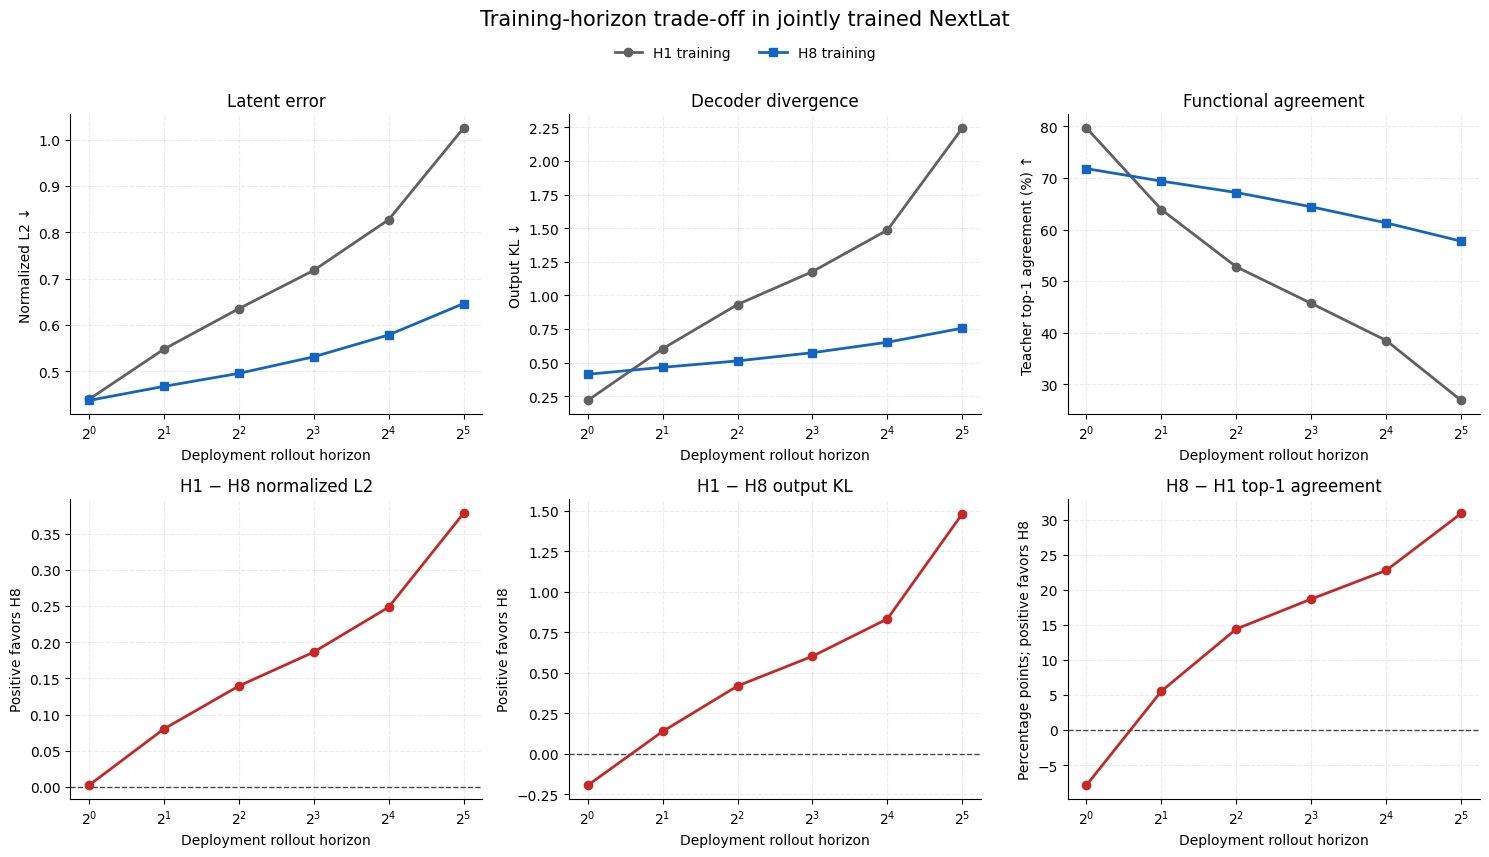

Saved PNG: /content/drive/MyDrive/ma2288_nextlat/research_v3/results/figures/nextlat_h1_vs_h8_crossover_seed42.png
Saved PDF: /content/drive/MyDrive/ma2288_nextlat/research_v3/results/figures/nextlat_h1_vs_h8_crossover_seed42.pdf

Cell 20 final crossover figure passed.


In [22]:
# Cell 20 — Create final H1/H8 crossover figure

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

figure_data = (
    full_h1_h8_recursive_df.copy()
)

h1_figure_data = (
    figure_data[
        figure_data["model"] == "H1 training"
    ]
    .sort_values("horizon")
)

h8_figure_data = (
    figure_data[
        figure_data["model"] == "H8 training"
    ]
    .sort_values("horizon")
)

colors = {
    "H1 training": "#616161",
    "H8 training": "#1565C0",
}

markers = {
    "H1 training": "o",
    "H8 training": "s",
}

figure, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8.2),
)

# ------------------------------------------------------------------
# Top row: absolute metrics
# ------------------------------------------------------------------

for model_name, model_df in [
    ("H1 training", h1_figure_data),
    ("H8 training", h8_figure_data),
]:
    axes[0, 0].plot(
        model_df["horizon"],
        model_df["normalized_l2"],
        marker=markers[model_name],
        linewidth=2,
        markersize=6,
        color=colors[model_name],
        label=model_name,
    )

    axes[0, 1].plot(
        model_df["horizon"],
        model_df["output_kl"],
        marker=markers[model_name],
        linewidth=2,
        markersize=6,
        color=colors[model_name],
        label=model_name,
    )

    axes[0, 2].plot(
        model_df["horizon"],
        100.0
        * model_df[
            "top1_teacher_agreement"
        ],
        marker=markers[model_name],
        linewidth=2,
        markersize=6,
        color=colors[model_name],
        label=model_name,
    )

axes[0, 0].set_title("Latent error")
axes[0, 0].set_ylabel("Normalized L2 ↓")

axes[0, 1].set_title("Decoder divergence")
axes[0, 1].set_ylabel("Output KL ↓")

axes[0, 2].set_title("Functional agreement")
axes[0, 2].set_ylabel(
    "Teacher top-1 agreement (%) ↑"
)


# ------------------------------------------------------------------
# Bottom row: paired H8 improvement with bootstrap CI
# ------------------------------------------------------------------

improvement_plot_specifications = [
    (
        "normalized_l2_improvement",
        "H1 − H8 normalized L2",
        "Positive favors H8",
        1.0,
    ),
    (
        "output_kl_improvement",
        "H1 − H8 output KL",
        "Positive favors H8",
        1.0,
    ),
    (
        "top1_agreement_improvement",
        "H8 − H1 top-1 agreement",
        "Percentage points; positive favors H8",
        100.0,
    ),
]

for column_index, (
    metric_name,
    axis_title,
    axis_label,
    scale,
) in enumerate(
    improvement_plot_specifications
):
    metric_df = (
        h1_h8_bootstrap_df[
            h1_h8_bootstrap_df["metric"]
            == metric_name
        ]
        .sort_values("horizon")
    )

    point_estimate = (
        scale
        * metric_df[
            "point_estimate"
        ].to_numpy()
    )

    confidence_lower = (
        scale
        * metric_df[
            "ci_lower"
        ].to_numpy()
    )

    confidence_upper = (
        scale
        * metric_df[
            "ci_upper"
        ].to_numpy()
    )

    error_bars = np.vstack(
        [
            point_estimate
            - confidence_lower,
            confidence_upper
            - point_estimate,
        ]
    )

    axes[1, column_index].errorbar(
        metric_df["horizon"],
        point_estimate,
        yerr=error_bars,
        marker="o",
        linewidth=2,
        markersize=6,
        capsize=3,
        color="#C62828",
    )

    axes[1, column_index].axhline(
        0.0,
        color="black",
        linewidth=1,
        linestyle="--",
        alpha=0.7,
    )

    axes[1, column_index].set_title(
        axis_title
    )

    axes[1, column_index].set_ylabel(
        axis_label
    )


# ------------------------------------------------------------------
# Shared styling
# ------------------------------------------------------------------

for axis in axes.flat:
    axis.set_xlabel("Deployment rollout horizon")
    axis.set_xticks(probe_horizons)
    axis.set_xscale("log", base=2)
    axis.grid(
        True,
        linestyle="--",
        alpha=0.25,
    )
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

handles, labels = (
    axes[0, 0].get_legend_handles_labels()
)

figure.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 1.01),
)

figure.suptitle(
    "Training-horizon trade-off in jointly trained NextLat",
    fontsize=15,
    y=1.04,
)

figure.tight_layout()

H1_H8_FIGURE_PNG_PATH = (
    V3_FIGURES_DIR
    / "nextlat_h1_vs_h8_crossover_seed42.png"
)

H1_H8_FIGURE_PDF_PATH = (
    V3_FIGURES_DIR
    / "nextlat_h1_vs_h8_crossover_seed42.pdf"
)

figure.savefig(
    H1_H8_FIGURE_PNG_PATH,
    dpi=220,
    bbox_inches="tight",
)

figure.savefig(
    H1_H8_FIGURE_PDF_PATH,
    bbox_inches="tight",
)

plt.show()

print("Saved PNG:", H1_H8_FIGURE_PNG_PATH)
print("Saved PDF:", H1_H8_FIGURE_PDF_PATH)

assert H1_H8_FIGURE_PNG_PATH.exists()
assert H1_H8_FIGURE_PDF_PATH.exists()

print("\nCell 20 final crossover figure passed.")

In [23]:
# Cell 21 — Save final Notebook 22 summary and README section

import json
from pathlib import Path

horizon_1_comparison = (
    full_h1_h8_comparison_df[
        full_h1_h8_comparison_df["horizon"] == 1
    ].iloc[0]
)

horizon_8_comparison = (
    full_h1_h8_comparison_df[
        full_h1_h8_comparison_df["horizon"] == 8
    ].iloc[0]
)

horizon_32_comparison = (
    full_h1_h8_comparison_df[
        full_h1_h8_comparison_df["horizon"] == 32
    ].iloc[0]
)

notebook22_summary = {
    "experiment": (
        "matched_nextlat_h1_vs_h8_training"
    ),
    "official_repository": (
        "https://github.com/JaydenTeoh/NextLat"
    ),
    "official_commit": OFFICIAL_COMMIT,
    "dataset": "cyrilzhang/TinyStories2-ascii",
    "evaluation_split": "validation",
    "independent_test_split": False,
    "seed": 42,
    "shared_training_protocol": {
        "training_steps": 5000,
        "tokens_per_model": 81920000,
        "effective_batch_size": 64,
        "sequence_length": 256,
        "layers": 4,
        "heads": 4,
        "hidden_dimension": 256,
        "vocabulary_size": 1000,
        "precision": "bf16-mixed",
        "gpu": torch.cuda.get_device_name(0),
    },
    "training_horizons": {
        "baseline": 1,
        "multihorizon": 8,
    },
    "training_cost": {
        "h1_elapsed_minutes":
            8.19673719878333,
        "h8_elapsed_minutes":
            training_elapsed_seconds / 60.0,
        "h8_to_h1_time_ratio":
            (
                training_elapsed_seconds / 60.0
            )
            / 8.19673719878333,
    },
    "language_modeling": {
        "h1_validation_next_token_loss":
            float(
                final_comparison[
                    "h1_next_token_loss"
                ]
            ),
        "h8_validation_next_token_loss":
            float(
                final_comparison[
                    "h8_next_token_loss"
                ]
            ),
        "h1_validation_perplexity":
            float(
                final_comparison[
                    "h1_perplexity"
                ]
            ),
        "h8_validation_perplexity":
            float(
                final_comparison[
                    "h8_perplexity"
                ]
            ),
    },
    "recursive_results": (
        full_h1_h8_recursive_df.to_dict(
            orient="records"
        )
    ),
    "h8_improvement_over_h1": (
        full_h1_h8_comparison_df.to_dict(
            orient="records"
        )
    ),
    "paired_bootstrap": (
        h1_h8_bootstrap_df.to_dict(
            orient="records"
        )
    ),
    "main_findings": [
        (
            "Training horizon and deployment horizon are "
            "not interchangeable."
        ),
        (
            "H8 training significantly worsens one-step "
            "decoder output KL and top-1 teacher agreement."
        ),
        (
            "The functional comparison reverses between "
            "deployment horizons 1 and 2."
        ),
        (
            "From horizons 2 through 32, H8 training "
            "significantly improves output KL and top-1 "
            "teacher agreement."
        ),
        (
            "At horizon 8, H8 training reduces output KL "
            f"by {horizon_8_comparison['output_kl_reduction_percent']:.2f}%."
        ),
        (
            "At horizon 32, H8 training reduces output KL "
            f"by {horizon_32_comparison['output_kl_reduction_percent']:.2f}%."
        ),
        (
            "H8 slightly improves one-step normalized L2 "
            "while substantially worsening one-step decoder "
            "KL, confirming that latent distance alone does "
            "not determine functional quality."
        ),
    ],
    "limitations": [
        "single training seed",
        "single small model scale",
        "TinyStories validation split only",
        "no independent TinyStories test split",
        "teacher-token-conditioned rollout",
        "no strong alternative learned-dynamics baseline",
        "no out-of-distribution dataset",
        "context length limited to 256 tokens",
        "no end-to-end speculative decoding measurement",
        (
            "packed-sequence bootstrap does not capture "
            "training-seed or model-scale uncertainty"
        ),
    ],
    "next_experiments": [
        "repeat H1/H8 comparison across at least three seeds",
        "evaluate out-of-distribution text with the same tokenizer",
        "train or evaluate a longer-context configuration",
        "compare fixed and cost-aware deployment horizons",
        "measure real decoding acceptance and wall-clock latency",
    ],
}

NOTEBOOK22_SUMMARY_PATH = (
    V3_METADATA_DIR
    / "notebook22_final_summary_seed42.json"
)

with open(
    NOTEBOOK22_SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as summary_file:
    json.dump(
        notebook22_summary,
        summary_file,
        indent=2,
    )


# ------------------------------------------------------------------
# README-ready Markdown
# ------------------------------------------------------------------

readme_section = f"""## Research V3: Multi-horizon NextLat training

We reproduced the official NextLat training setup on TinyStories and
compared two matched models trained with latent-prediction horizons
of 1 and 8. Both models used the same architecture, seed, optimizer,
81.92 million training tokens, and NVIDIA L4 environment.

### Main result

The training horizon creates a measurable short-versus-long-horizon
trade-off:

- At deployment horizon 1, horizon-8 training increases decoder output
  KL and reduces teacher top-1 agreement.
- The comparison reverses between deployment horizons 1 and 2.
- At deployment horizon 8, horizon-8 training reduces output KL by
  {horizon_8_comparison['output_kl_reduction_percent']:.2f}%.
- At deployment horizon 32, horizon-8 training reduces output KL by
  {horizon_32_comparison['output_kl_reduction_percent']:.2f}%.
- Horizon-8 training used
  {(training_elapsed_seconds / 60.0) / 8.19673719878333:.2f} times
  the wall-clock training time of horizon-1 training.
- Horizon-8 training did not degrade next-token validation perplexity
  in this run: {final_comparison['h1_perplexity']:.4f} for H1 versus
  {final_comparison['h8_perplexity']:.4f} for H8.

Paired bootstrap intervals over 26,688 packed validation sequences
confirm that the one-step functional degradation and the horizon
2–32 improvements are statistically stable within this validation
split.

![H1 versus H8 crossover](results/figures/nextlat_h1_vs_h8_crossover_seed42.png)

### Interpretation

These results suggest that training and deployment horizons should be
selected jointly. Optimizing longer recursive rollouts can trade away
one-step decoder fidelity while substantially improving long-horizon
functional stability. The one-step latent L2 and decoder-space metrics
also move in different directions, so latent distance alone is not a
sufficient proxy for functional rollout quality.

### Limitations

This is a single-seed, small-model validation result on TinyStories.
The dataset provides no independent test split in the official data
module. The rollout is conditioned on true future token embeddings,
and no end-to-end speculative decoding speedup is claimed.
"""

NOTEBOOK22_README_PATH = (
    V3_METADATA_DIR
    / "notebook22_readme_section.md"
)

with open(
    NOTEBOOK22_README_PATH,
    "w",
    encoding="utf-8",
) as readme_file:
    readme_file.write(readme_section)


# ------------------------------------------------------------------
# Artifact manifest
# ------------------------------------------------------------------

artifact_paths = [
    H8_100_CONFIG_PATH,
    H8_5000_CONFIG_PATH,
    H1_H8_CURVE_PATH,
    FULL_H1_H8_RESULTS_PATH,
    FULL_H1_H8_COMPARISON_PATH,
    H1_H8_SEQUENCE_STATISTICS_PATH,
    H1_H8_BOOTSTRAP_PATH,
    H1_H8_METADATA_PATH,
    H1_H8_BOOTSTRAP_METADATA_PATH,
    NOTEBOOK22_SUMMARY_PATH,
    NOTEBOOK22_README_PATH,
    H1_H8_FIGURE_PNG_PATH,
    H1_H8_FIGURE_PDF_PATH,
]

print("=" * 120)
print("NOTEBOOK 22 ARTIFACT MANIFEST")
print("=" * 120)

for artifact_path in artifact_paths:
    assert artifact_path.exists()

    print(
        f"{artifact_path.relative_to(V3_ROOT)!s:100s} "
        f"{artifact_path.stat().st_size / 1024**2:.3f} MB"
    )

print("\n" + "=" * 120)
print("NOTEBOOK 22 FINAL FINDINGS")
print("=" * 120)

for finding in notebook22_summary[
    "main_findings"
]:
    print("-", finding)

print("\nSaved final summary:", NOTEBOOK22_SUMMARY_PATH)
print("Saved README section:", NOTEBOOK22_README_PATH)

print("\nNOTEBOOK 22 COMPLETE.")

NOTEBOOK 22 ARTIFACT MANIFEST
configs/multihorizon/tinystories_nextlat_h8_100step_seed42.yaml                                      0.001 MB
configs/multihorizon/tinystories_nextlat_h8_5000step_seed42.yaml                                     0.001 MB
results/tables/nextlat_h1_vs_h8_training_curve_seed42.csv                                            0.002 MB
results/tables/full_validation_h1_vs_h8_recursive_seed42.csv                                         0.002 MB
results/tables/full_validation_h8_improvement_over_h1_seed42.csv                                     0.001 MB
results/tables/validation_h1_vs_h8_sequence_statistics_seed42.csv                                    29.547 MB
results/tables/validation_h1_vs_h8_paired_bootstrap_seed42.csv                                       0.002 MB
results/metadata/nextlat_h1_vs_h8_training_seed42.json                                               0.001 MB
results/metadata/validation_h1_vs_h8_paired_bootstrap_seed42.json                        